# Non-cheatable ICL tasks: nonce-word transformations + arithmetic

20 tasks with no output-vocabulary shortcut.
- 10 nonce-word transformations (character-level operations on CVCVC nonsense words)
- 10 arithmetic tasks (y = ax + b for various a, b; outputs are just numbers)

**Strict correctness**: no whitespace normalization. Internal newlines/spaces break a match.
**Subsampling**: generate 200 prompts per task, filter to orig-correct, keep ≤50.

In [5]:
import sys; sys.path.insert(0, '../..')
import torch, numpy as np, matplotlib.pyplot as plt, random, seaborn as sns
import pandas as pd, pickle
from collections import defaultdict
from tqdm import tqdm
from transformer_lens import HookedTransformer

try:
    from configs import MODEL_NAME
except ImportError:
    MODEL_NAME = 'meta-llama/Llama-3.2-3B'

%matplotlib inline
sns.set_context('notebook')

model = HookedTransformer.from_pretrained(MODEL_NAME, device='cuda', dtype=torch.float16)
model.eval()
n_layers = model.cfg.n_layers
n_heads  = model.cfg.n_heads
d_model  = model.cfg.d_model
PATTERN_FILTER = lambda name: 'attn.hook_pattern' in name
RESID_FILTER   = lambda name: 'hook_resid_pre' in name

2026-04-30 00:33:49.938636: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.16s/it]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer


In [6]:
def build_icl_prompt(demo_pairs, query_input):
    lines = [f'{inp} → {out}' for inp, out in demo_pairs]
    lines.append(f'{query_input} →')
    return '\n'.join(lines)

def find_per_demo_positions(model, prompt, demos):
    """Find token positions of each demo's input and output in the tokenized prompt."""
    tokens = model.to_tokens(prompt, prepend_bos=True)[0]
    full_decoded = model.tokenizer.decode(tokens)
    # char → token index mapping
    char_to_tok = []
    for i in range(len(tokens)):
        s = model.tokenizer.decode([tokens[i].item()])
        char_to_tok.extend([i] * len(s))

    def span_to_toks(start, end):
        if start < 0 or end > len(char_to_tok): return []
        return sorted(set(char_to_tok[start:end]))

    result = []
    search_from = 0
    for inp, out in demos:
        demo = {'input_positions': [], 'output_positions': []}
        inp_s, out_s = str(inp), str(out)
        idx = full_decoded.find(inp_s, search_from)
        if idx >= 0:
            demo['input_positions'] = span_to_toks(idx, idx + len(inp_s))
            search_from = idx + len(inp_s)
        arrow = full_decoded.find('→', search_from)
        if arrow >= 0:
            oidx = full_decoded.find(out_s, arrow)
            if oidx >= 0:
                demo['output_positions'] = span_to_toks(oidx, oidx + len(out_s))
                search_from = oidx + len(out_s)
        result.append(demo)
    return result


## Strict multi-token correctness check

No whitespace collapsing — `blurg\nblurg` ≠ `blurgblurg`.
Only leading/trailing whitespace is stripped.

In [7]:
@torch.no_grad()
def check_correct_multitoken(model, tokens, expected, max_new_tokens=20, hooks=None):
    target = expected.strip()
    generated = []
    cur = tokens.clone()
    for _ in range(max_new_tokens):
        if hooks:
            logits = model.run_with_hooks(cur, fwd_hooks=hooks)[0, -1]
        else:
            logits = model(cur)[0, -1]
        nt = logits.argmax().item()
        generated.append(nt)
        cur = torch.cat([cur, torch.tensor([[nt]], device=cur.device)], dim=1)
        decoded = model.tokenizer.decode(generated).strip()
        if decoded == target:
            return 1
        # If we've generated enough chars and it doesn't match, fail
        if len(decoded) >= len(target):
            return 0
        # Early exit: generated prefix diverges from target
        if decoded and not target.startswith(decoded):
            return 0
    return int(model.tokenizer.decode(generated).strip() == target)

@torch.no_grad()
def target_logprob(model, tokens, expected, hooks=None):
    target_ids = model.to_tokens(' ' + expected.strip(), prepend_bos=False)[0].tolist()
    total = 0.0
    cur = tokens.clone()
    for tok in target_ids:
        if hooks:
            logits = model.run_with_hooks(cur, fwd_hooks=hooks)[0, -1]
        else:
            logits = model(cur)[0, -1]
        lp = torch.log_softmax(logits.float(), dim=-1)
        total += lp[tok].item()
        cur = torch.cat([cur, torch.tensor([[tok]], device=cur.device)], dim=1)
    return total

@torch.no_grad()
def first_content_token_rank(model, tokens, expected, hooks=None):
    """Rank of the first non-space token, after feeding any leading spaces."""
    target_toks = model.to_tokens(' ' + expected.strip(), prepend_bos=False)[0]
    space_id = model.to_tokens(' ', prepend_bos=False)[0, 0].item()
    cur = tokens.clone()
    for t in target_toks:
        if t.item() != space_id:
            if hooks:
                logits = model.run_with_hooks(cur, fwd_hooks=hooks)[0, -1]
            else:
                logits = model(cur)[0, -1]
            return int((logits > logits[t.item()]).sum().item())
        else:
            cur = torch.cat([cur, t.view(1, 1).to(cur.device)], dim=1)
    return 0

def content_token_rank_from_logits(model, logits, expected):
    """Rank of first non-space token in expected, measured at current position.
    No autoregressive feeding — pure logit lens at the patched site."""
    target_toks = model.to_tokens(' ' + expected.strip(), prepend_bos=False)[0]
    space_id = model.to_tokens(' ', prepend_bos=False)[0, 0].item()
    for t in target_toks:
        if t.item() != space_id:
            return int((logits > logits[t.item()]).sum().item())
    return 0

## Task generators

**Nonce-word tasks (10):** character-level transformations on 5-char CVCVC nonsense words.
**Arithmetic tasks (10):** y = ax + b for various (a, b). Outputs are numbers — no vocabulary shortcut.

In [8]:
CONSONANTS = 'bdfghjklmnprstvwz'
VOWELS = 'aeiou'

def make_nonsense(length, rng):
    pattern = [CONSONANTS, VOWELS] * (length // 2 + 1)
    return ''.join(rng.choice(p) for p in pattern[:length])

# --- Nonce-word generators ---
# Each returns (demo_pairs, query_input, query_output)

def _gen_nonce(rng, transform_fn, word_len=5):
    """Generic nonce-word task generator."""
    words = []
    while len(set(words)) < 11:
        words = [make_nonsense(word_len, rng) for _ in range(11)]
    demo_pairs = [(w, transform_fn(w)) for w in words[:10]]
    qi = words[10]
    return demo_pairs, qi, transform_fn(qi)

def gen_repetition(rng):
    return _gen_nonce(rng, lambda x: x + x)

def gen_prepend_first(rng):
    return _gen_nonce(rng, lambda x: x[0] + x)

def gen_append_last(rng):
    return _gen_nonce(rng, lambda x: x + x[-1])

def gen_drop_first(rng):
    return _gen_nonce(rng, lambda x: x[1:])

def gen_drop_last(rng):
    return _gen_nonce(rng, lambda x: x[:-1])

def gen_reverse(rng):
    return _gen_nonce(rng, lambda x: x[::-1])

def gen_swap_ends(rng):
    return _gen_nonce(rng, lambda x: x[-1] + x[1:-1] + x[0])

def gen_rotate_left(rng):
    return _gen_nonce(rng, lambda x: x[1:] + x[0])

def gen_suffix_ed(rng):
    return _gen_nonce(rng, lambda x: x + 'ed')

def gen_double_vowels(rng):
    def transform(x):
        return ''.join(c * 2 if c in VOWELS else c for c in x)
    return _gen_nonce(rng, transform)

# --- Arithmetic generators ---

def _gen_arith(rng, fn, lo, hi):
    """Generic arithmetic task generator."""
    pool = list(range(lo, hi + 1))
    rng.shuffle(pool)
    nums = pool[:11]
    demo_pairs = [(str(n), str(fn(n))) for n in nums[:10]]
    qi = str(nums[10])
    return demo_pairs, qi, str(fn(nums[10]))

def gen_add_3(rng):     return _gen_arith(rng, lambda x: x + 3, 1, 50)
def gen_add_7(rng):     return _gen_arith(rng, lambda x: x + 7, 1, 50)
def gen_add_13(rng):    return _gen_arith(rng, lambda x: x + 13, 1, 50)
def gen_mul_2(rng):     return _gen_arith(rng, lambda x: 2*x, 1, 50)
def gen_mul_3(rng):     return _gen_arith(rng, lambda x: 3*x, 1, 30)
def gen_mul_5(rng):     return _gen_arith(rng, lambda x: 5*x, 1, 20)
def gen_mul_10(rng):    return _gen_arith(rng, lambda x: 10*x, 1, 20)
def gen_mul_2_add_1(rng): return _gen_arith(rng, lambda x: 2*x + 1, 1, 50)
def gen_mul_3_add_2(rng): return _gen_arith(rng, lambda x: 3*x + 2, 1, 30)
def gen_mul_2_sub_1(rng): return _gen_arith(rng, lambda x: 2*x - 1, 1, 50)

TASK_GENERATORS = {
    # Nonce-word
    'repetition':     gen_repetition,
    'prepend_first':  gen_prepend_first,
    'append_last':    gen_append_last,
    'drop_first':     gen_drop_first,
    'drop_last':      gen_drop_last,
    'reverse':        gen_reverse,
    'swap_ends':      gen_swap_ends,
    'rotate_left':    gen_rotate_left,
    'suffix_ed':      gen_suffix_ed,
    'double_vowels':  gen_double_vowels,
    # Arithmetic
    'add_3':          gen_add_3,
    'add_7':          gen_add_7,
    'add_13':         gen_add_13,
    'mul_2':          gen_mul_2,
    'mul_3':          gen_mul_3,
    'mul_5':          gen_mul_5,
    'mul_10':         gen_mul_10,
    'mul_2_add_1':    gen_mul_2_add_1,
    'mul_3_add_2':    gen_mul_3_add_2,
    'mul_2_sub_1':    gen_mul_2_sub_1,
}
TASK_NAMES = list(TASK_GENERATORS.keys())
NONCE_TASKS = TASK_NAMES[:10]
ARITH_TASKS = TASK_NAMES[10:]
print(f'{len(NONCE_TASKS)} nonce tasks, {len(ARITH_TASKS)} arithmetic tasks')
for name in TASK_NAMES:
    rng = random.Random(0)
    demos, qi, qo = TASK_GENERATORS[name](rng)
    print(f'  {name:18s}  {demos[0][0]:>12s} → {demos[0][1]:<14s}  query: {qi} → {qo}')

10 nonce tasks, 10 arithmetic tasks
  repetition                 sodiz → sodizsodiz      query: fapuw → fapuwfapuw
  prepend_first              sodiz → ssodiz          query: fapuw → ffapuw
  append_last                sodiz → sodizz          query: fapuw → fapuww
  drop_first                 sodiz → odiz            query: fapuw → apuw
  drop_last                  sodiz → sodi            query: fapuw → fapu
  reverse                    sodiz → zidos           query: fapuw → wupaf
  swap_ends                  sodiz → zodis           query: fapuw → wapuf
  rotate_left                sodiz → odizs           query: fapuw → apuwf
  suffix_ed                  sodiz → sodized         query: fapuw → fapuwed
  double_vowels              sodiz → soodiiz         query: fapuw → faapuuw
  add_3                         44 → 47              query: 34 → 37
  add_7                         44 → 51              query: 34 → 41
  add_13                        44 → 57              query: 34 → 47
  mul_2    

## Build prompts, run sanity check, subsample successes

Generate 200 prompts per task. Run strict orig check. Filter to correct.
Keep up to 50 successes per task.

In [9]:
import os, pickle

SAVE_PATH = 'filtered_prompts.pkl'
N_RAW = 200
N_KEEP = 50

def build_prompts_data(task_name, n_prompts, seed):
    rng = random.Random(seed)
    gen = TASK_GENERATORS[task_name]
    out = []
    for _ in range(n_prompts):
        demo_pairs, qi, qo = gen(rng)
        prompt = build_icl_prompt(demo_pairs, qi)
        out.append({'demo_pairs': demo_pairs, 'query_input': qi,
                    'query_output': qo, 'prompt': prompt})
    return out

if os.path.exists(SAVE_PATH):
    print(f'Loading filtered prompts from {SAVE_PATH}...')
    with open(SAVE_PATH, 'rb') as f:
        saved = pickle.load(f)
    TASKS = saved['TASKS']
    TASK_NAMES_ACTIVE = saved['TASK_NAMES_ACTIVE']
    print(f'Loaded {len(TASK_NAMES_ACTIVE)} active tasks:')
    for name in TASK_NAMES_ACTIVE:
        print(f'  {name:<18s} n={len(TASKS[name])}')
else:
    print(f'No saved prompts found. Generating {N_RAW} per task and filtering...')
    RAW_TASKS = {name: build_prompts_data(name, N_RAW, seed=hash(name) % 10**6)
                 for name in TASK_NAMES}

    raw_correct = {}
    for name in TASK_NAMES:
        correct = []
        for pdata in tqdm(RAW_TASKS[name], desc=name, leave=False):
            tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
            correct.append(check_correct_multitoken(model, tokens, pdata['query_output']))
            torch.cuda.empty_cache()
        raw_correct[name] = correct

    print(f'\n{"Task":<18s} {"Orig":>6s} {"n_correct":>10s} {"kept":>6s}')
    print('-' * 44)
    TASKS = {}
    for name in TASK_NAMES:
        rc = raw_correct[name]
        n_corr = sum(rc)
        acc = n_corr / len(rc)
        good_idx = [i for i, c in enumerate(rc) if c]
        if len(good_idx) > N_KEEP:
            rng_sub = random.Random(42)
            good_idx = sorted(rng_sub.sample(good_idx, N_KEEP))
        TASKS[name] = [RAW_TASKS[name][i] for i in good_idx]
        print(f'{name:<18s} {acc:>6.3f} {n_corr:>10d} {len(TASKS[name]):>6d}')

    TASK_NAMES_ACTIVE = [n for n in TASK_NAMES if len(TASKS[n]) >= 5]
    dropped = [n for n in TASK_NAMES if n not in TASK_NAMES_ACTIVE]
    if dropped:
        print(f'\nDropped (< 5 successes): {dropped}')
    print(f'\nActive tasks: {len(TASK_NAMES_ACTIVE)}')

    # Save
    with open(SAVE_PATH, 'wb') as f:
        pickle.dump({'TASKS': TASKS, 'TASK_NAMES_ACTIVE': TASK_NAMES_ACTIVE}, f)
    print(f'\nSaved to {SAVE_PATH}')


Loading filtered prompts from filtered_prompts.pkl...
Loaded 20 active tasks:
  repetition         n=50
  prepend_first      n=50
  append_last        n=50
  drop_first         n=50
  drop_last          n=50
  reverse            n=12
  swap_ends          n=13
  rotate_left        n=42
  suffix_ed          n=50
  double_vowels      n=50
  add_3              n=50
  add_7              n=50
  add_13             n=50
  mul_2              n=50
  mul_3              n=50
  mul_5              n=50
  mul_10             n=50
  mul_2_add_1        n=50
  mul_3_add_2        n=35
  mul_2_sub_1        n=50


In [10]:
print('Query-only check (should be ~0 for genuine ICL tasks)...')
for name in TASK_NAMES_ACTIVE:
    qo_correct = []
    for pdata in TASKS[name][:20]:  # check on subset for speed
        zs = f'{pdata["query_input"]} →'
        zs_tokens = model.to_tokens(zs, prepend_bos=True)
        qo_correct.append(check_correct_multitoken(model, zs_tokens, pdata['query_output']))
        torch.cuda.empty_cache()
    print(f'  {name:<18s} query_only={np.mean(qo_correct):.3f}')

Query-only check (should be ~0 for genuine ICL tasks)...
  repetition         query_only=0.000
  prepend_first      query_only=0.000
  append_last        query_only=0.000


KeyboardInterrupt: 

## Build per-task input/output pools for manipulation conditions

In [11]:
W_E = model.W_E.detach()
task_pools = {}
for name in TASK_NAMES_ACTIVE:
    in_pool, in_tokids = [], []
    out_pool, out_tokids = [], []
    for pdata in TASKS[name]:
        for inp, out in pdata['demo_pairs']:
            in_pool.append(inp)
            in_tokids.append(model.to_tokens(' ' + str(inp), prepend_bos=False)[0, 0].item())
            out_pool.append(out)
            out_tokids.append(model.to_tokens(' ' + str(out), prepend_bos=False)[0, 0].item())
    task_pools[name] = {
        'in_pool': in_pool, 'out_pool': out_pool,
        'mean_in_embed':  W_E[in_tokids].float().mean(dim=0),
        'mean_out_embed': W_E[out_tokids].float().mean(dim=0),
    }

## Manipulation sweep

Conditions: orig, shuffled_inputs, random_inputs, mean_embed_inputs, star_inputs,
shuffled_outputs, random_outputs, mean_embed_outputs, star_outputs, query_only.

In [8]:
def make_embed_hook(positions, replacement_vec):
    def hook_fn(emb, hook):
        for p in positions:
            emb[:, p, :] = replacement_vec.to(emb.dtype)
        return emb
    return hook_fn

CONDS = ['orig', 'shuffled_inputs', 'random_inputs', 'mean_embed_inputs', 'star_inputs',
         'shuffled_outputs', 'random_outputs', 'mean_embed_outputs', 'star_outputs',
         'query_only']

task_correct = {name: {c: [] for c in CONDS} for name in TASK_NAMES_ACTIVE}
task_logp    = {name: {c: [] for c in CONDS} for name in TASK_NAMES_ACTIVE}

for name in TASK_NAMES_ACTIVE:
    rng = random.Random(7)
    pools = task_pools[name]
    for pdata in tqdm(TASKS[name], desc=f'{name} sweep'):
        demos = pdata['demo_pairs']
        qi, ans = pdata['query_input'], pdata['query_output']
        inputs  = [i for i, _ in demos]
        outputs = [o for _, o in demos]
        inputs_shuffled  = inputs.copy();  rng.shuffle(inputs_shuffled)
        outputs_shuffled = outputs.copy(); rng.shuffle(outputs_shuffled)
        inputs_random    = [rng.choice(pools['in_pool'])  for _ in inputs]
        outputs_random   = [rng.choice(pools['out_pool']) for _ in outputs]

        prompts = {
            'orig':              pdata['prompt'],
            'shuffled_inputs':   build_icl_prompt(list(zip(inputs_shuffled, outputs)), qi),
            'random_inputs':     build_icl_prompt(list(zip(inputs_random, outputs)), qi),
            'star_inputs':       build_icl_prompt([('*', o) for o in outputs], qi),
            'shuffled_outputs':  build_icl_prompt(list(zip(inputs, outputs_shuffled)), qi),
            'random_outputs':    build_icl_prompt(list(zip(inputs, outputs_random)), qi),
            'star_outputs':      build_icl_prompt([(i, '*') for i in inputs], qi),
            'query_only':        f'{qi} →',
        }
        tokens = {k: model.to_tokens(v, prepend_bos=True) for k, v in prompts.items()}

        for k in prompts:
            task_correct[name][k].append(
                check_correct_multitoken(model, tokens[k], ans))
            task_logp[name][k].append(
                target_logprob(model, tokens[k], ans))

        # Mean-embed conditions: hooks on the orig tokenization
        per_demo = find_per_demo_positions(model, prompts['orig'], demos)
        in_pos  = [p for d in per_demo for p in d.get('input_positions', [])]
        out_pos = [p for d in per_demo for p in d.get('output_positions', [])]

        if in_pos:
            h_in = [('hook_embed', make_embed_hook(in_pos, pools['mean_in_embed']))]
            task_correct[name]['mean_embed_inputs'].append(
                check_correct_multitoken(model, tokens['orig'], ans, hooks=h_in))
            task_logp[name]['mean_embed_inputs'].append(
                target_logprob(model, tokens['orig'], ans, hooks=h_in))
        else:
            task_correct[name]['mean_embed_inputs'].append(0)
            task_logp[name]['mean_embed_inputs'].append(-100.0)

        if out_pos:
            h_out = [('hook_embed', make_embed_hook(out_pos, pools['mean_out_embed']))]
            task_correct[name]['mean_embed_outputs'].append(
                check_correct_multitoken(model, tokens['orig'], ans, hooks=h_out))
            task_logp[name]['mean_embed_outputs'].append(
                target_logprob(model, tokens['orig'], ans, hooks=h_out))
        else:
            task_correct[name]['mean_embed_outputs'].append(0)
            task_logp[name]['mean_embed_outputs'].append(-100.0)

        torch.cuda.empty_cache()

    for c in CONDS:
        task_correct[name][c] = np.array(task_correct[name][c])
        task_logp[name][c]    = np.array(task_logp[name][c])

print('Sweep complete')

add_13 sweep:  32%|███▏      | 16/50 [00:28<01:01,  1.81s/it]


KeyboardInterrupt: 

## Manipulation sweep: accuracy by condition, per task

/tmp/ipykernel_3551998/1274783140.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='Correct', order=order_labels,
/tmp/ipykernel_3551998/1274783140.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='Correct', order=order_labels,
/tmp/ipykernel_3551998/1274783140.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='Correct', order=order_labels,
/tmp/ipykernel_3551998/1274783140.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

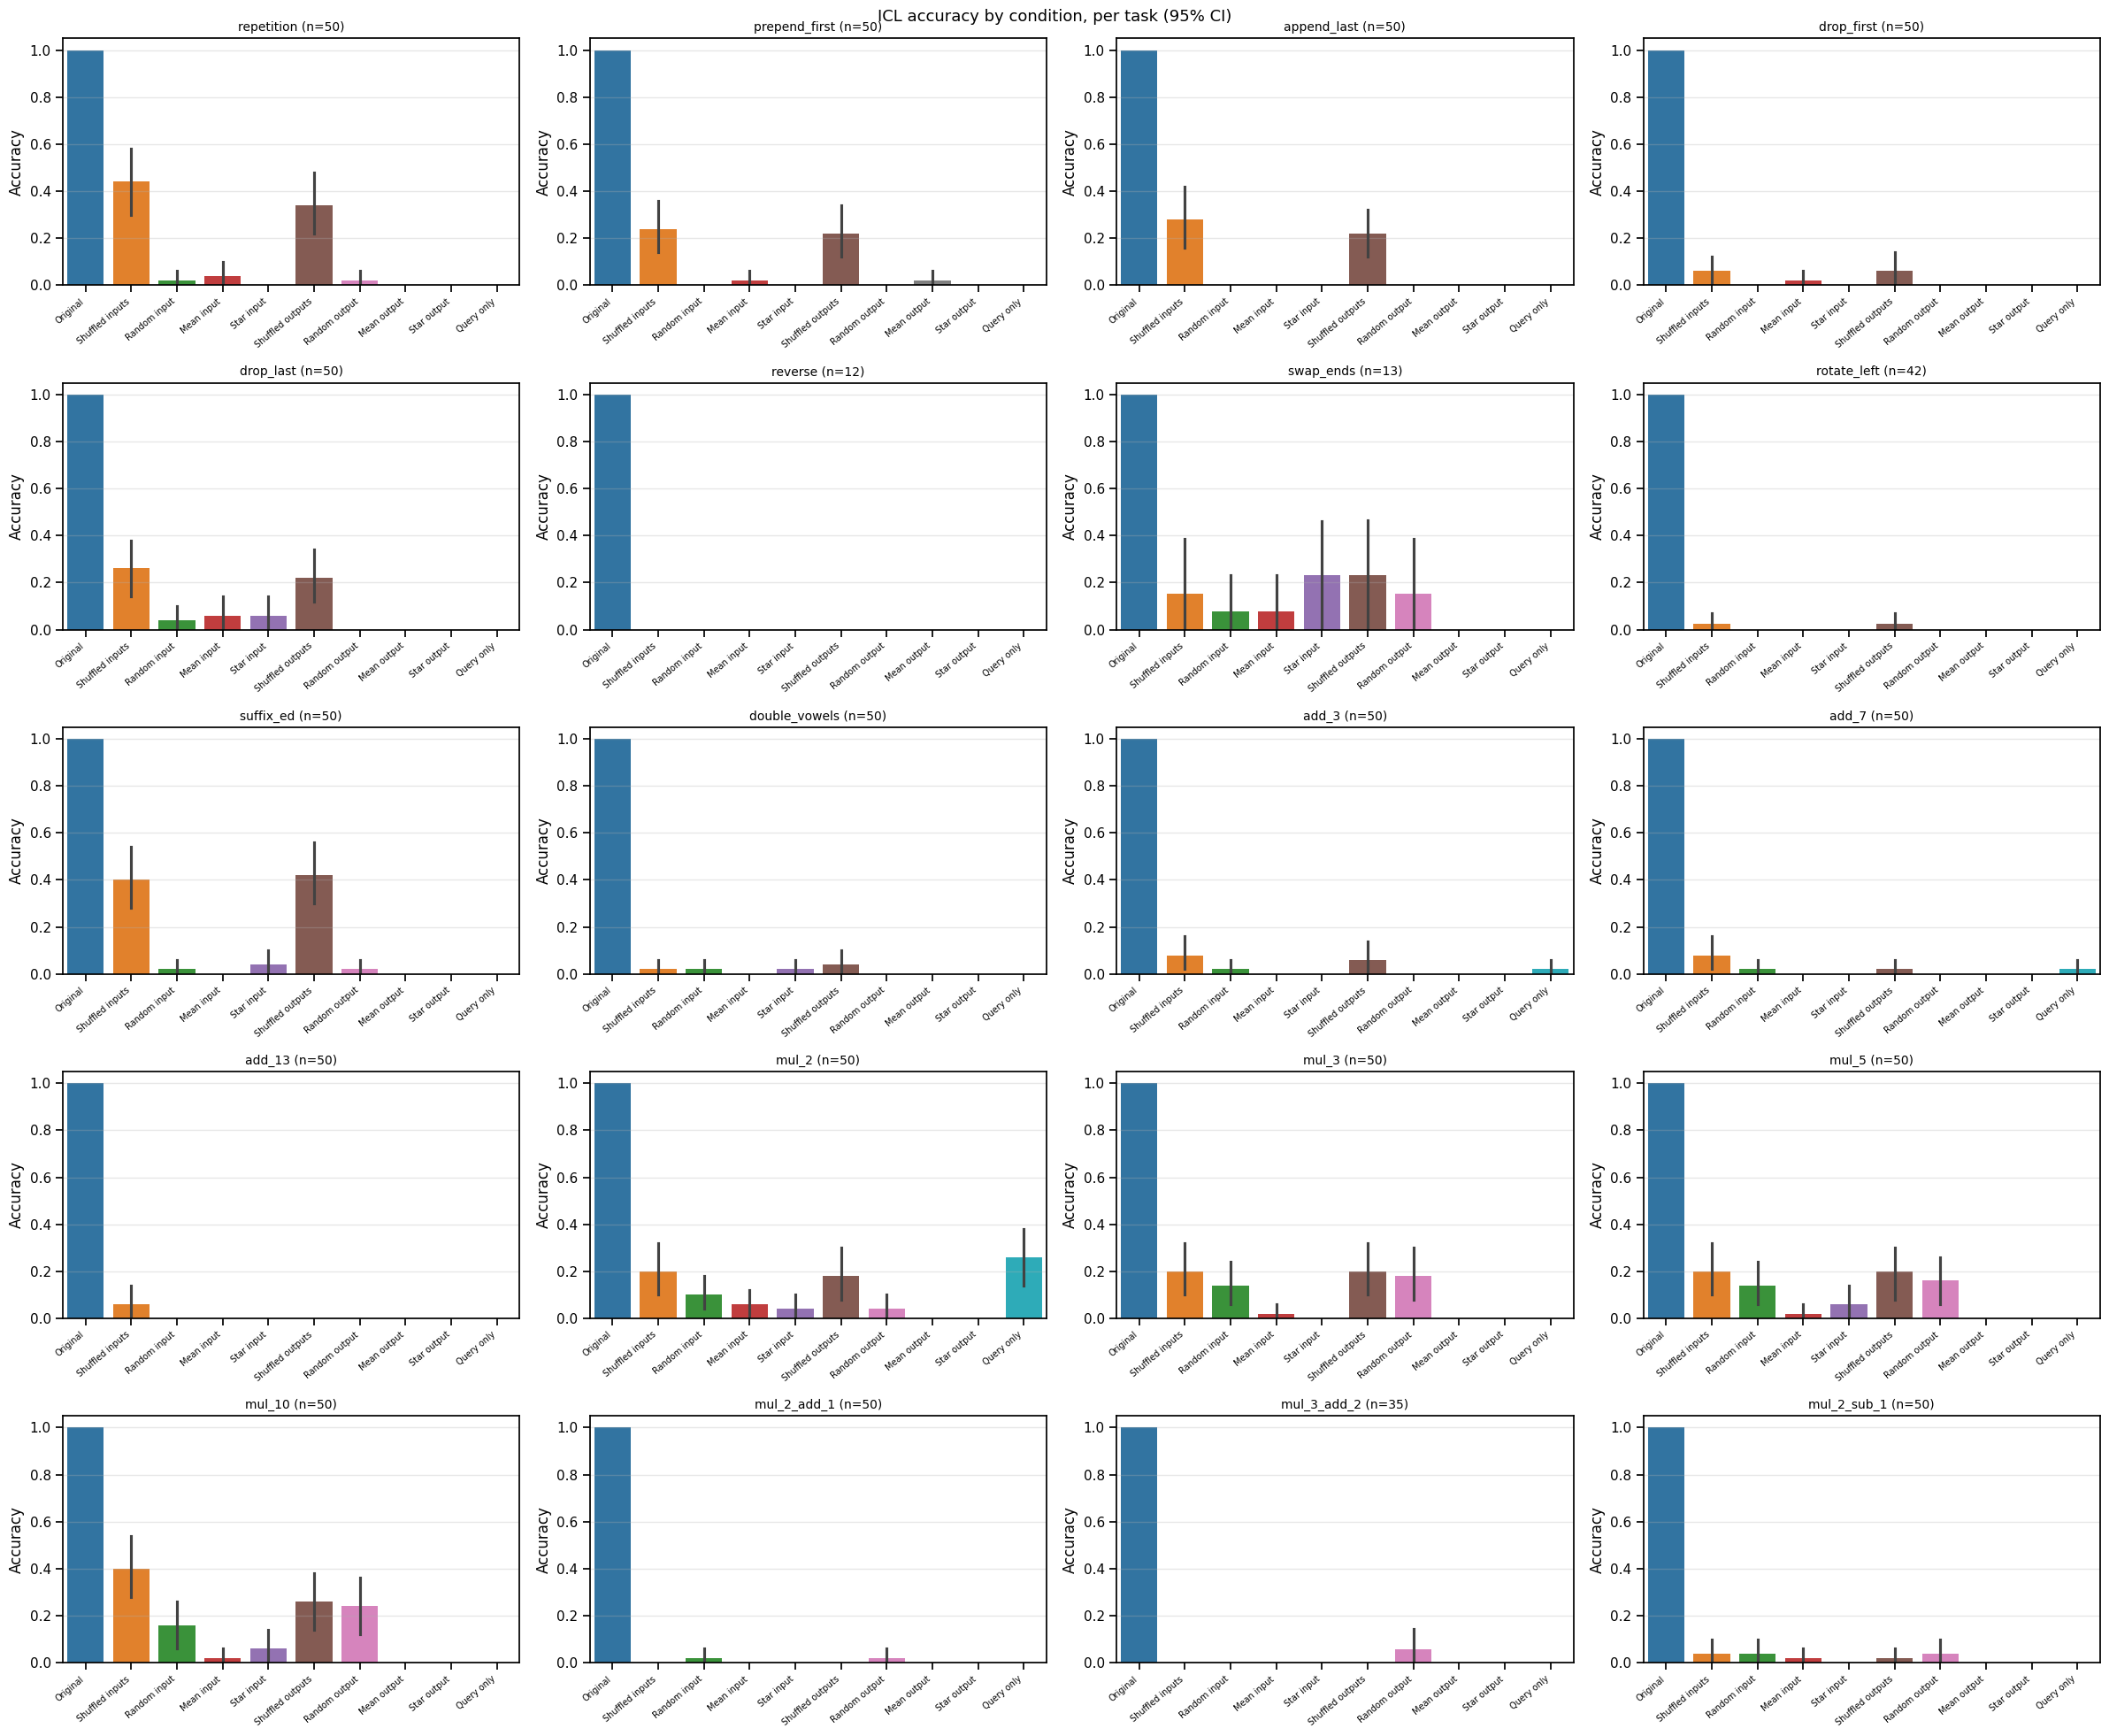

In [9]:
tick_map = {
    'orig':                'Original',
    'shuffled_inputs':     'Shuffled inputs',
    'random_inputs':       'Random input',
    'mean_embed_inputs':   'Mean input',
    'star_inputs':         'Star input',
    'shuffled_outputs':    'Shuffled outputs',
    'random_outputs':      'Random output',
    'mean_embed_outputs':  'Mean output',
    'star_outputs':        'Star output',
    'query_only':          'Query only',
}
order_keys = CONDS
order_labels = [tick_map[c] for c in order_keys]

n_t = len(TASK_NAMES_ACTIVE)
n_cols = 4
n_rows = int(np.ceil(n_t / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = np.array(axes).flatten()
for ax, name in zip(axes, TASK_NAMES_ACTIVE):
    correct = task_correct[name]
    df = pd.DataFrame({
        'Condition': np.concatenate([[tick_map[c]] * len(correct[c]) for c in order_keys]),
        'Correct':   np.concatenate([correct[c] for c in order_keys]),
    })
    sns.barplot(data=df, x='Condition', y='Correct', order=order_labels,
                palette='tab10', errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_ylabel('Accuracy'); ax.set_xlabel('')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'{name} (n={len(correct["orig"])})', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=7)
for ax in axes[n_t:]: ax.set_visible(False)
fig.suptitle('ICL accuracy by condition, per task (95% CI)', fontsize=13)
plt.tight_layout(); plt.show()

/tmp/ipykernel_3551998/150131490.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='LogProb', order=order_labels,
/tmp/ipykernel_3551998/150131490.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='LogProb', order=order_labels,
/tmp/ipykernel_3551998/150131490.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='LogProb', order=order_labels,
/tmp/ipykernel_3551998/150131490.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

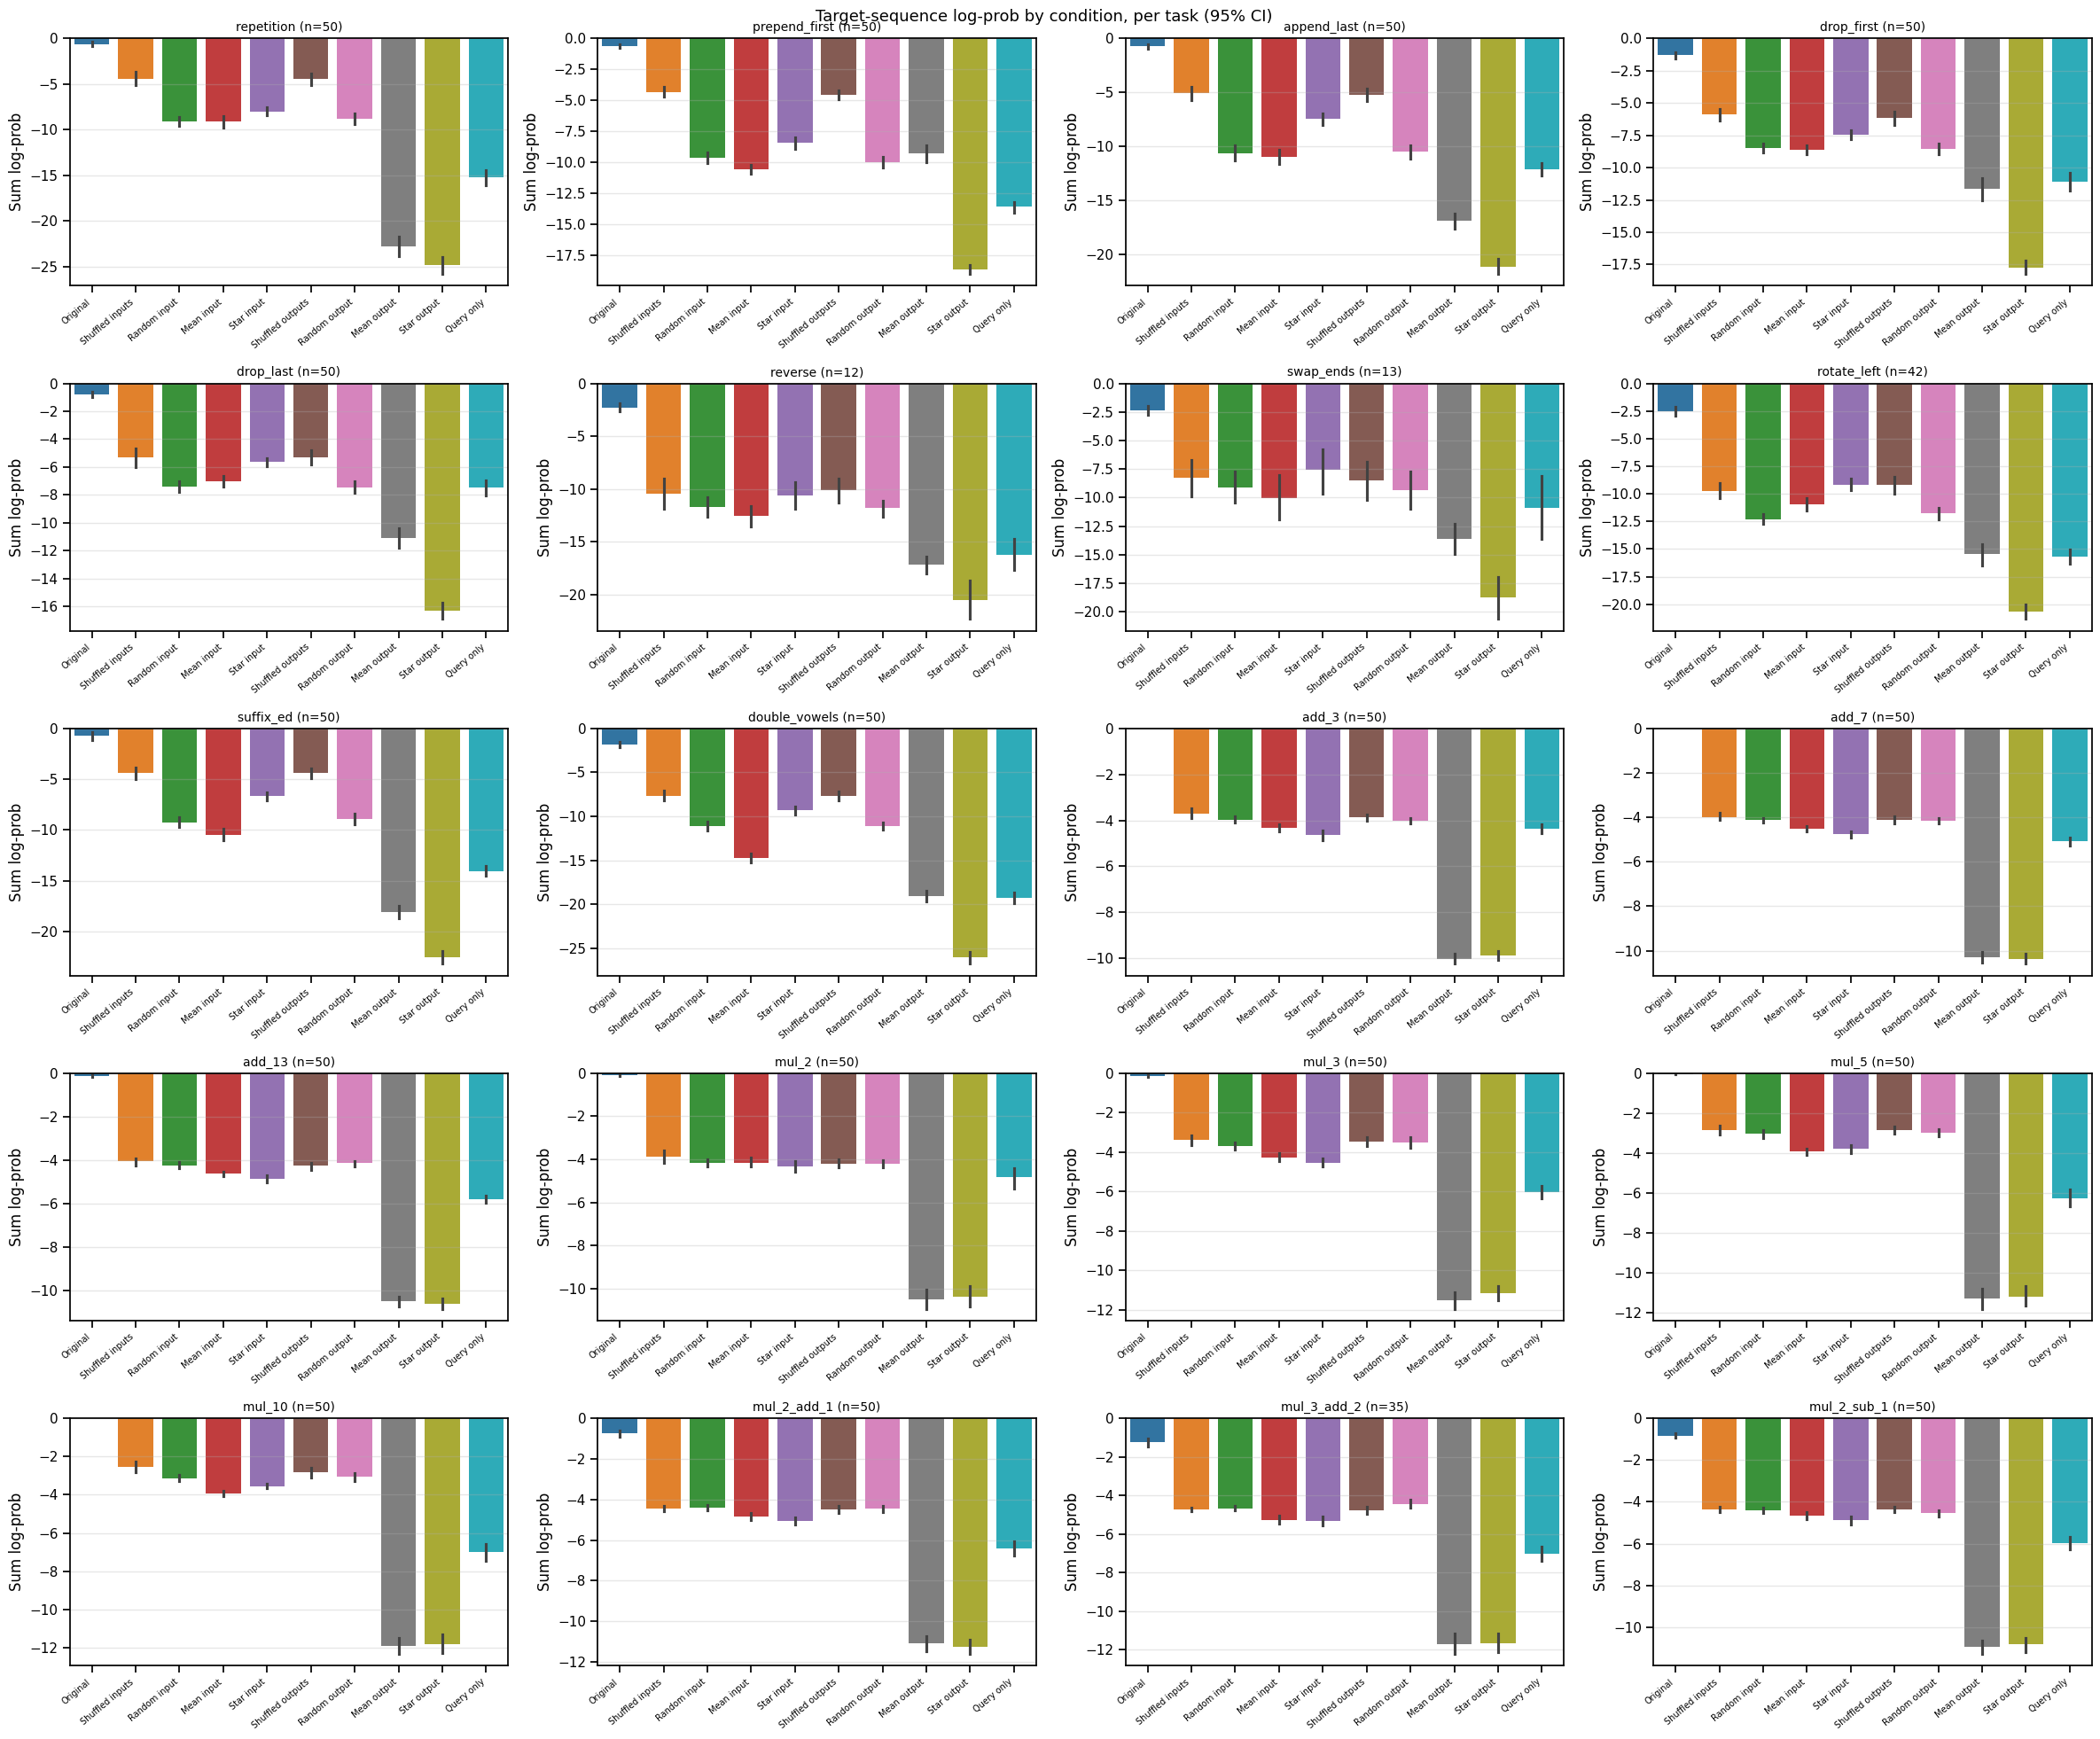

In [10]:
# Log-prob version
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = np.array(axes).flatten()
for ax, name in zip(axes, TASK_NAMES_ACTIVE):
    logp = task_logp[name]
    df = pd.DataFrame({
        'Condition': np.concatenate([[tick_map[c]] * len(logp[c]) for c in order_keys]),
        'LogProb':   np.concatenate([logp[c] for c in order_keys]),
    })
    sns.barplot(data=df, x='Condition', y='LogProb', order=order_labels,
                palette='tab10', errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_ylabel('Sum log-prob'); ax.set_xlabel('')
    ax.set_title(f'{name} (n={len(logp["orig"])})', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=7)
for ax in axes[n_t:]: ax.set_visible(False)
fig.suptitle('Target-sequence log-prob by condition, per task (95% CI)', fontsize=13)
plt.tight_layout(); plt.show()

In [11]:
print(f'\n{"Task":<18s}', end='')
for c in CONDS:
    print(f' {tick_map[c][:8]:>9s}', end='')
print()
print('-' * (18 + 9 * len(CONDS) + len(CONDS)))
for name in TASK_NAMES_ACTIVE:
    print(f'{name:<18s}', end='')
    for c in CONDS:
        print(f' {task_correct[name][c].mean():>9.3f}', end='')
    print()


Task                Original  Shuffled  Random i  Mean inp  Star inp  Shuffled  Random o  Mean out  Star out  Query on
----------------------------------------------------------------------------------------------------------------------
repetition             1.000     0.440     0.020     0.040     0.000     0.340     0.020     0.000     0.000     0.000
prepend_first          1.000     0.240     0.000     0.020     0.000     0.220     0.000     0.020     0.000     0.000
append_last            1.000     0.280     0.000     0.000     0.000     0.220     0.000     0.000     0.000     0.000
drop_first             1.000     0.060     0.000     0.020     0.000     0.060     0.000     0.000     0.000     0.000
drop_last              1.000     0.260     0.040     0.060     0.060     0.220     0.000     0.000     0.000     0.000
reverse                1.000     0.000     0.000     0.000     0.000     0.000     0.000     0.000     0.000     0.000
swap_ends              1.000     0.154     0.07

# Output→input head scoring and ablation

## Score heads per task with baseline-subtracted output→input attention

In [12]:
def score_heads_on_prompts(prompts_data, desc='Scoring'):
    num_sum  = np.zeros((n_layers, n_heads), dtype=np.float64)
    base_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
    cnt = 0
    for pdata in tqdm(prompts_data, desc=desc, leave=False):
        demos = pdata['demo_pairs']
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        seq_len = tokens.shape[1]
        per_demo = find_per_demo_positions(model, pdata['prompt'], demos)
        all_in = set(); all_out = set()
        for d in per_demo:
            for p in d.get('input_positions', []):  all_in.add(p)
            for p in d.get('output_positions', []): all_out.add(p)
        num_mask = torch.zeros(seq_len, seq_len)
        for d in per_demo:
            for op in d.get('output_positions', []):
                for ip in d.get('input_positions', []):
                    num_mask[op, ip] = 1.0
        base_mask = torch.zeros(seq_len, seq_len)
        ins_list = sorted(all_in)
        for q in range(seq_len):
            if q in all_out: continue
            for ik in ins_list:
                if ik <= q: base_mask[q, ik] = 1.0
        n_num = int(num_mask.sum().item()); n_base = int(base_mask.sum().item())
        if n_num == 0 or n_base == 0: continue
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
        for L in range(n_layers):
            patt = cache['pattern', L][0].cpu().float()
            num_sum[L, :]  += (patt * num_mask).sum(dim=(1, 2)).numpy() / n_num
            base_sum[L, :] += (patt * base_mask).sum(dim=(1, 2)).numpy() / n_base
        cnt += 1
        del cache; torch.cuda.empty_cache()
    return (num_sum - base_sum) / max(cnt, 1), cnt

task_scores = {}
for name in TASK_NAMES_ACTIVE:
    sc, n_scored = score_heads_on_prompts(TASKS[name], desc=name)
    task_scores[name] = sc
    flat = sorted([(L, h, sc[L, h]) for L in range(n_layers) for h in range(n_heads)],
                  key=lambda x: -x[2])
    print(f'{name} top 3: ' + ', '.join(f'L{L}H{h} ({s:+.4f})' for L, h, s in flat[:3]))

repetition top 3: L4H14 (+0.2686), L8H8 (+0.2365), L13H14 (+0.2051)


prepend_first top 3: L13H13 (+0.2344), L4H14 (+0.2272), L8H8 (+0.2175)


append_last top 3: L4H14 (+0.2681), L8H8 (+0.2095), L16H3 (+0.1775)


drop_first top 3: L13H13 (+0.3487), L13H12 (+0.1860), L13H14 (+0.1600)


drop_last top 3: L13H13 (+0.3007), L4H14 (+0.2613), L5H8 (+0.2574)


...

mul_5 top 3: L9H18 (+0.4206), L9H17 (+0.3135), L10H18 (+0.3127)


mul_10 top 3: L13H13 (+0.5392), L9H18 (+0.3991), L10H10 (+0.3555)


mul_2_add_1 top 3: L5H17 (+0.3419), L10H18 (+0.3157), L10H10 (+0.2899)


mul_3_add_2 top 3: L10H18 (+0.3484), L9H18 (+0.3455), L9H17 (+0.3137)


mul_2_sub_1 top 3: L5H17 (+0.3679), L10H18 (+0.3234), L10H10 (+0.3066)


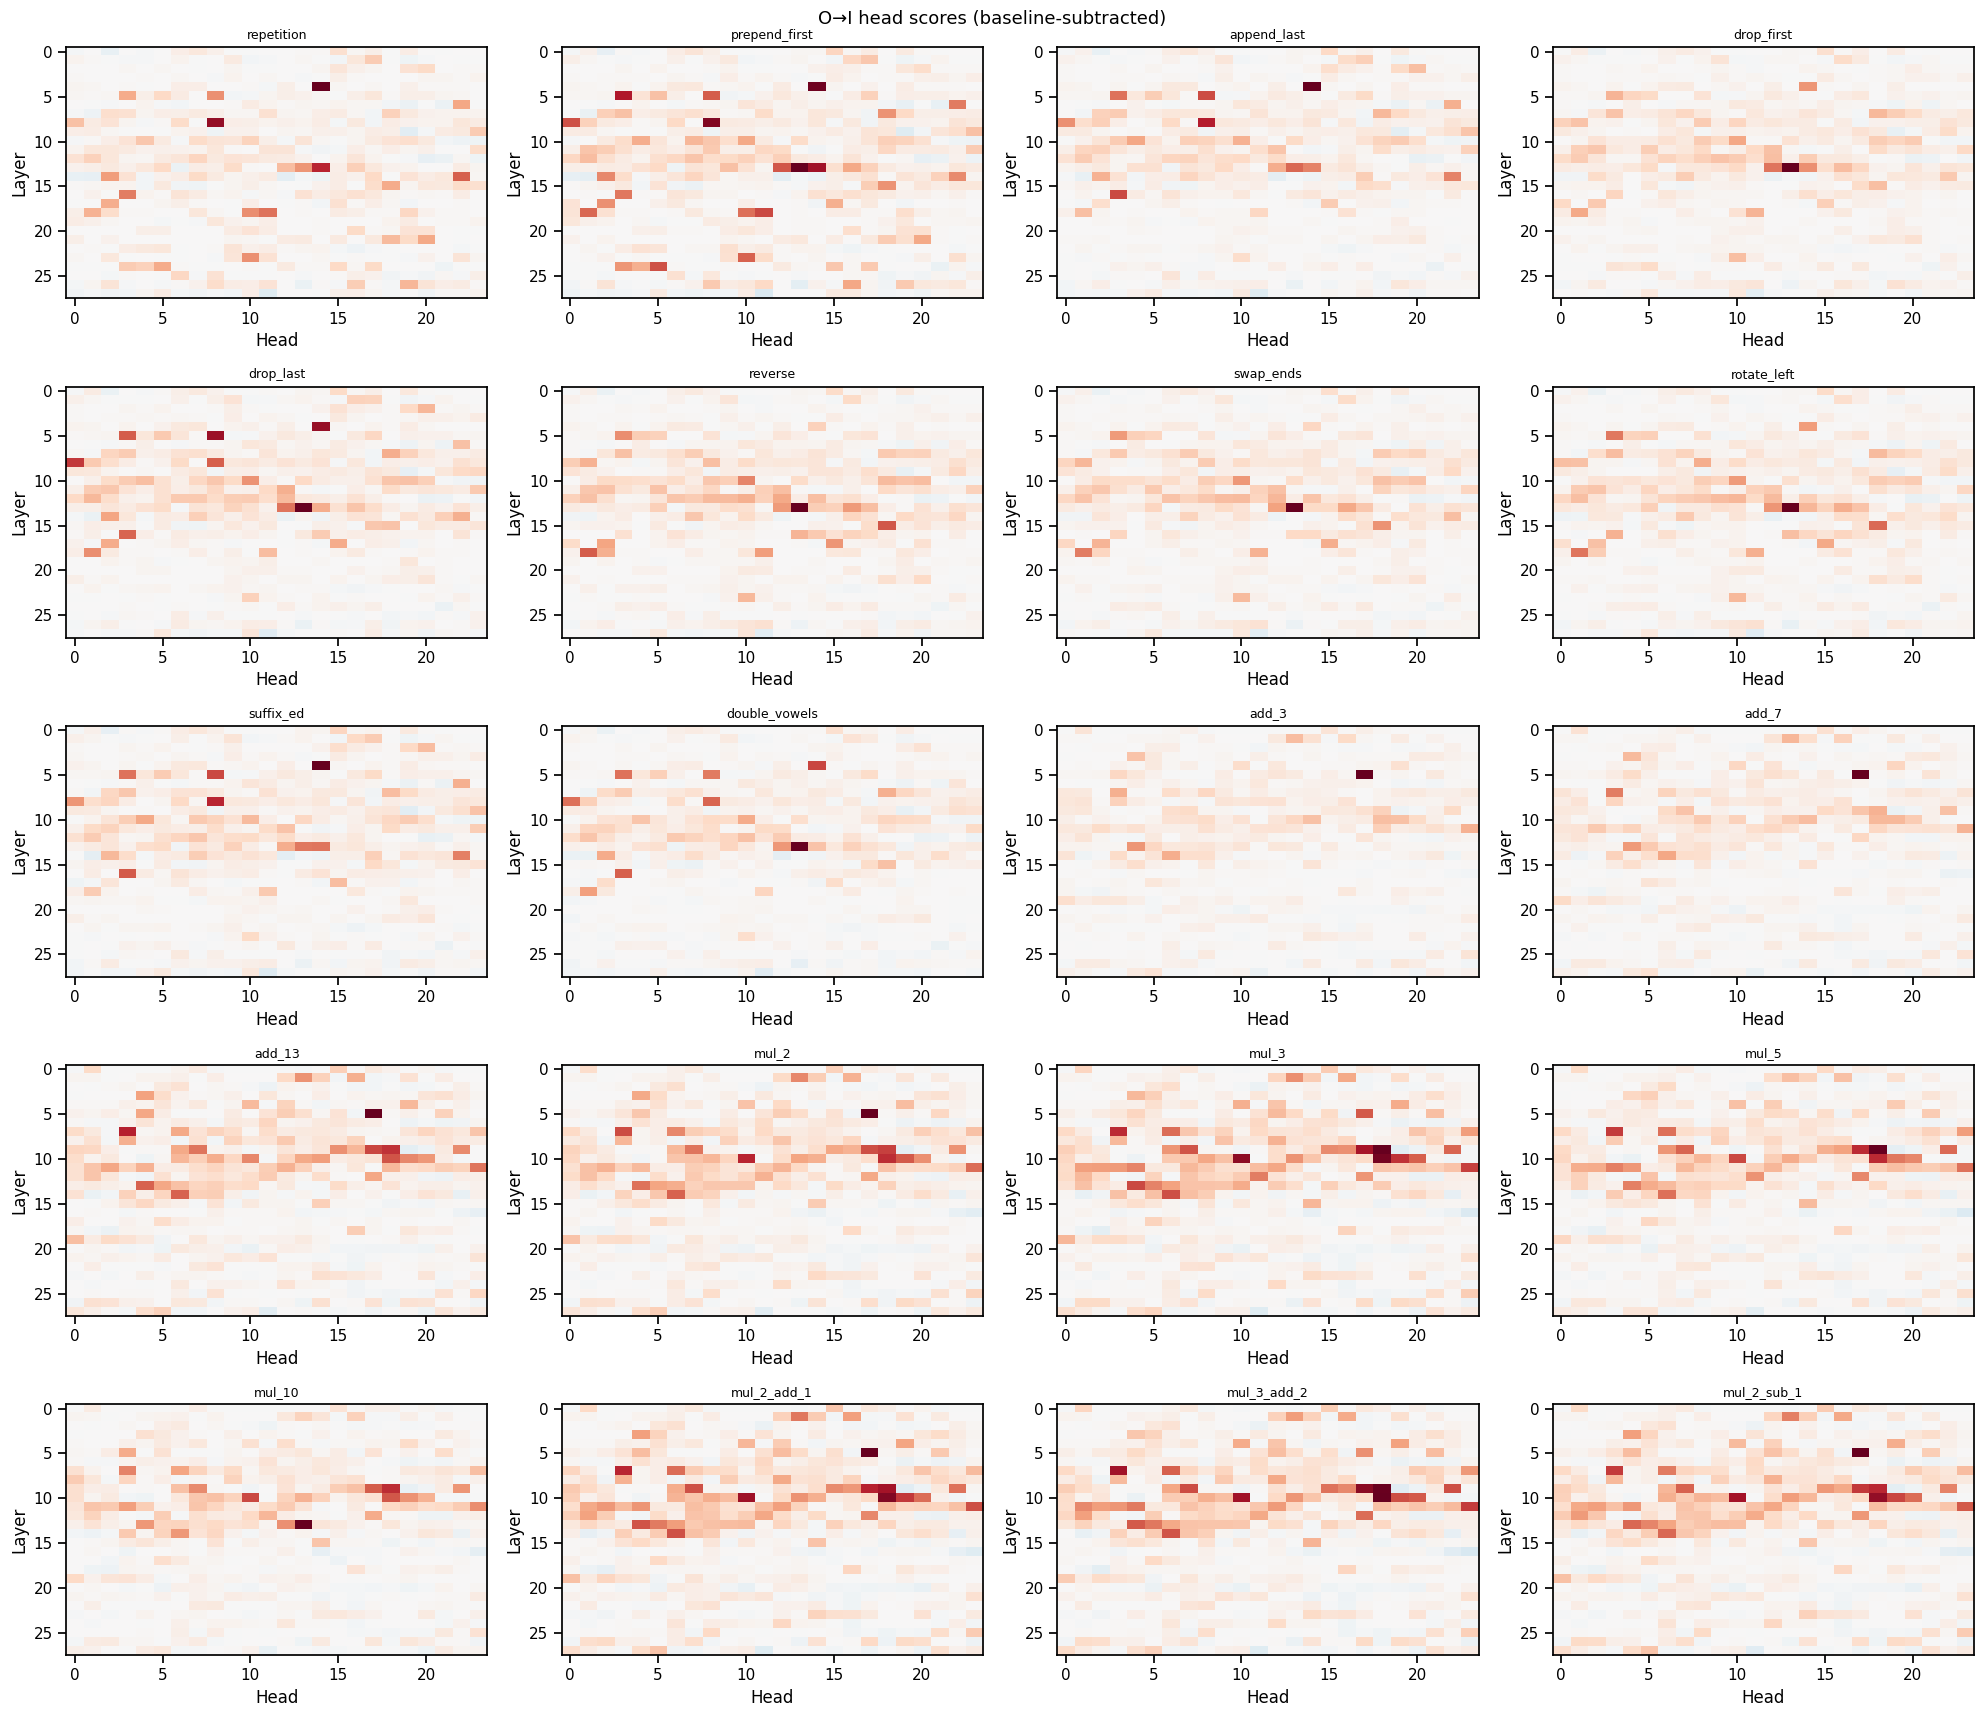

In [13]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows))
axes = np.array(axes).flatten()
for ax, name in zip(axes, TASK_NAMES_ACTIVE):
    sc = task_scores[name]
    im = ax.imshow(sc, aspect='auto', cmap='RdBu_r',
                   vmin=-np.abs(sc).max(), vmax=np.abs(sc).max())
    ax.set_xlabel('Head'); ax.set_ylabel('Layer')
    ax.set_title(name, fontsize=9)
for ax in axes[n_t:]: ax.set_visible(False)
fig.suptitle('O→I head scores (baseline-subtracted)', fontsize=13)
plt.tight_layout(); plt.show()

## Top-10% ablation vs random-10% control

In [14]:
def heads_by_layer(head_list):
    d = defaultdict(list)
    for L, h in head_list: d[L].append(h)
    return d

def make_ablation_hooks(hbl):
    hooks = []
    for L, h_list in hbl.items():
        def hook(z, hook, _hl=h_list):
            for h in _hl: z[0, :, h, :] = 0
            return z
        hooks.append((f'blocks.{L}.attn.hook_z', hook))
    return hooks

top10pct_n = max(1, int(0.10 * n_layers * n_heads))
all_pairs = [(L, h) for L in range(n_layers) for h in range(n_heads)]

task_top_heads = {}
task_rand_heads = {}
task_ablation_hooks = {}
for name in TASK_NAMES_ACTIVE:
    sc = task_scores[name]
    flat = sorted([(L, h, sc[L, h]) for L in range(n_layers) for h in range(n_heads)],
                  key=lambda x: -x[2])
    top10 = [(L, h) for L, h, _ in flat[:top10pct_n]]
    top10_set = set(top10)
    rng_r = random.Random(hash(name) % 10**6)
    rand10 = rng_r.sample([p for p in all_pairs if p not in top10_set], top10pct_n)
    task_top_heads[name] = top10
    task_rand_heads[name] = rand10
    task_ablation_hooks[name] = {
        'unablated': [],
        'top10': make_ablation_hooks(heads_by_layer(top10)),
        'rand10': make_ablation_hooks(heads_by_layer(rand10)),
    }

In [15]:
ABL_KEYS = ['unablated', 'top10', 'rand10']
ablation_results = {name: {ab: [] for ab in ABL_KEYS} for name in TASK_NAMES_ACTIVE}
ablation_rank    = {name: {ab: [] for ab in ABL_KEYS} for name in TASK_NAMES_ACTIVE}

for name in TASK_NAMES_ACTIVE:
    hooks_map = task_ablation_hooks[name]
    for pdata in tqdm(TASKS[name], desc=f'{name} ablation'):
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        ans = pdata['query_output']
        for ab in ABL_KEYS:
            h = hooks_map[ab] if hooks_map[ab] else None
            ablation_results[name][ab].append(
                check_correct_multitoken(model, tokens, ans, hooks=h))
            with torch.no_grad():
                if h:
                    logits = model.run_with_hooks(tokens, fwd_hooks=h)[0, -1]
                else:
                    logits = model(tokens)[0, -1]
            ablation_rank[name][ab].append(
                first_token_rank(model, logits, ans))
        torch.cuda.empty_cache()
    for ab in ABL_KEYS:
        ablation_results[name][ab] = np.array(ablation_results[name][ab])
        ablation_rank[name][ab]    = np.array(ablation_rank[name][ab])

mul_2_sub_1 ablation: 100%|██████████| 50/50 [00:19<00:00,  2.58it/s]


/tmp/ipykernel_3551998/3586773780.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ablation', y='Accuracy', order=ab_order_lab,
/tmp/ipykernel_3551998/3586773780.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ablation', y='Accuracy', order=ab_order_lab,
/tmp/ipykernel_3551998/3586773780.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ablation', y='Accuracy', order=ab_order_lab,
/tmp/ipykernel_3551998/3586773780.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

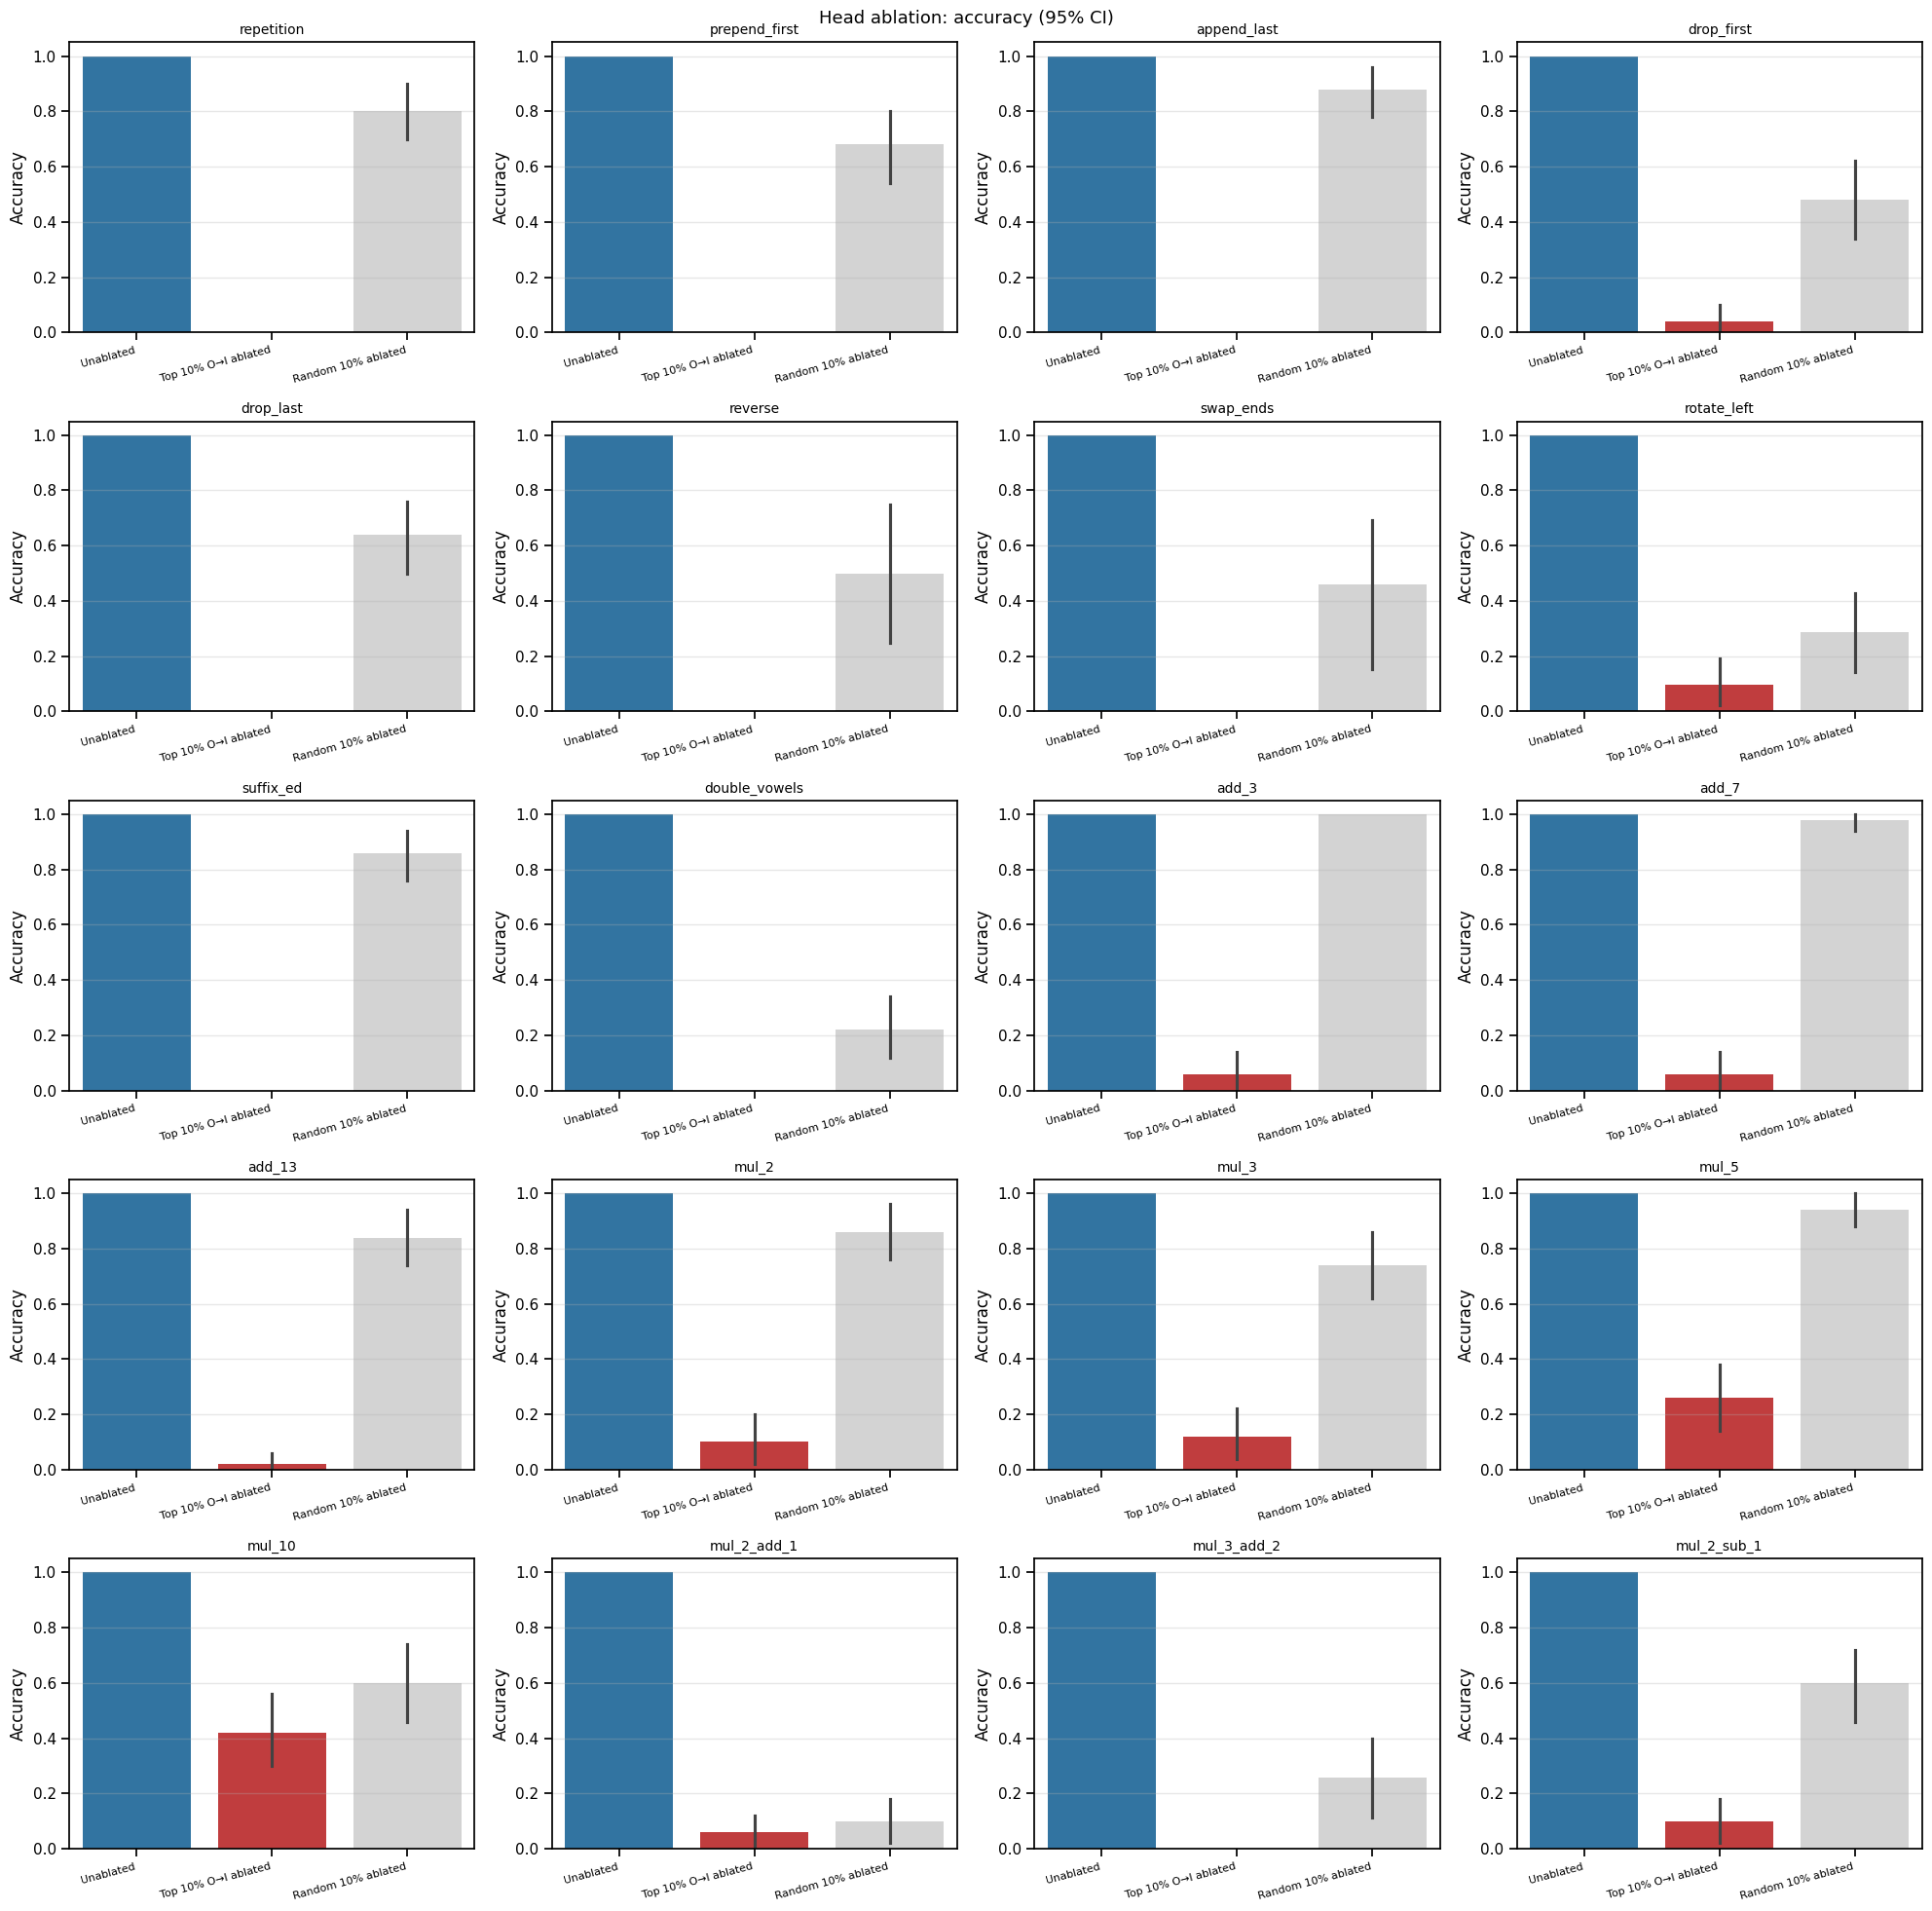

/tmp/ipykernel_3551998/3586773780.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ablation', y='Rank', order=ab_order_lab,
/tmp/ipykernel_3551998/3586773780.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ablation', y='Rank', order=ab_order_lab,
/tmp/ipykernel_3551998/3586773780.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ablation', y='Rank', order=ab_order_lab,
/tmp/ipykernel_3551998/3586773780.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

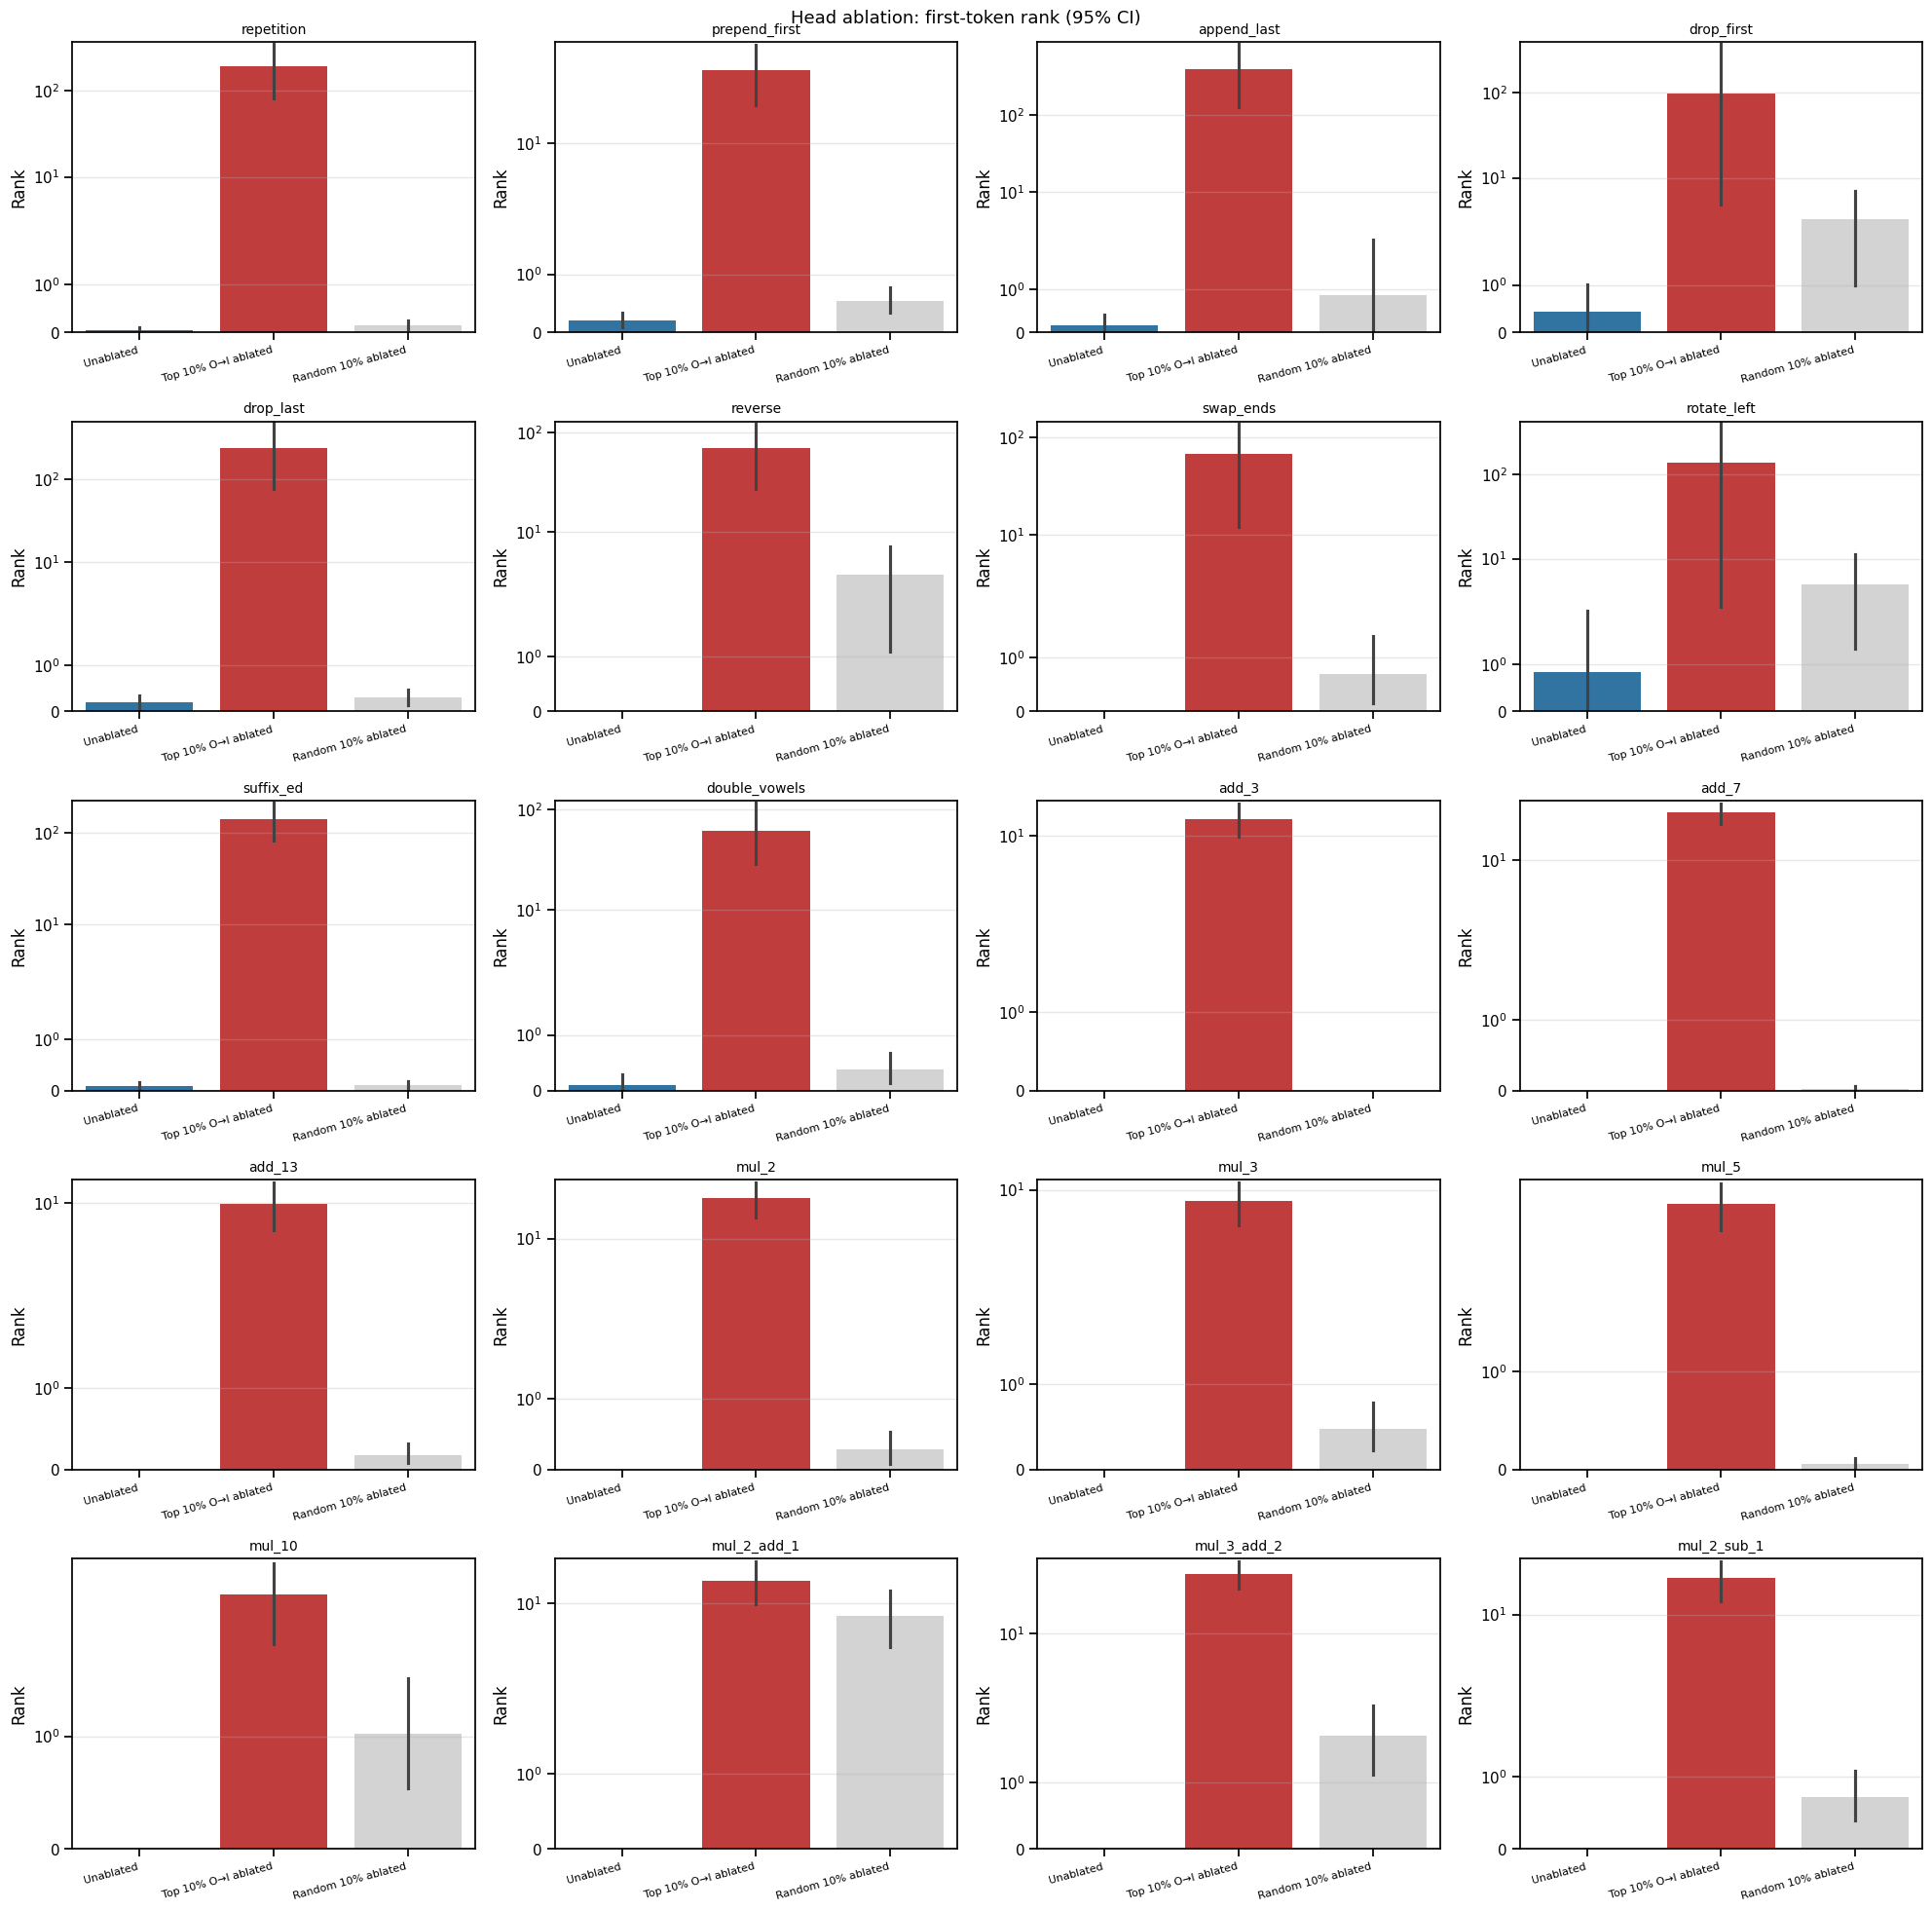

In [30]:
ab_label = {'unablated': 'Unablated', 'top10': 'Top 10% O→I ablated',
            'rand10': 'Random 10% ablated'}
ab_palette = {v: c for v, c in zip(ab_label.values(), ['tab:blue', 'tab:red', 'lightgray'])}
ab_order_lab = list(ab_label.values())

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = np.array(axes).flatten()
for ax, name in zip(axes, TASK_NAMES_ACTIVE):
    rows = [{'Ablation': ab_label[ab], 'Accuracy': v}
            for ab in ABL_KEYS for v in ablation_results[name][ab]]
    df = pd.DataFrame(rows)
    sns.barplot(data=df, x='Ablation', y='Accuracy', order=ab_order_lab,
                palette=[ab_palette[a] for a in ab_order_lab],
                errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_ylim(0, 1.05); ax.set_xlabel(''); ax.set_title(name, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=8)
for ax in axes[n_t:]: ax.set_visible(False)
fig.suptitle('Head ablation: accuracy (95% CI)', fontsize=13)
plt.tight_layout(); plt.show()

# Rank version
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = np.array(axes).flatten()
for ax, name in zip(axes, TASK_NAMES_ACTIVE):
    rows = [{'Ablation': ab_label[ab], 'Rank': v}
            for ab in ABL_KEYS for v in ablation_rank[name][ab]]
    df = pd.DataFrame(rows)
    sns.barplot(data=df, x='Ablation', y='Rank', order=ab_order_lab,
                palette=[ab_palette[a] for a in ab_order_lab],
                errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_yscale('symlog'); ax.set_xlabel(''); ax.set_title(name, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=8)
for ax in axes[n_t:]: ax.set_visible(False)
fig.suptitle('Head ablation: first-token rank (95% CI)', fontsize=13)
plt.tight_layout(); plt.show()

## Cross-task head overlap

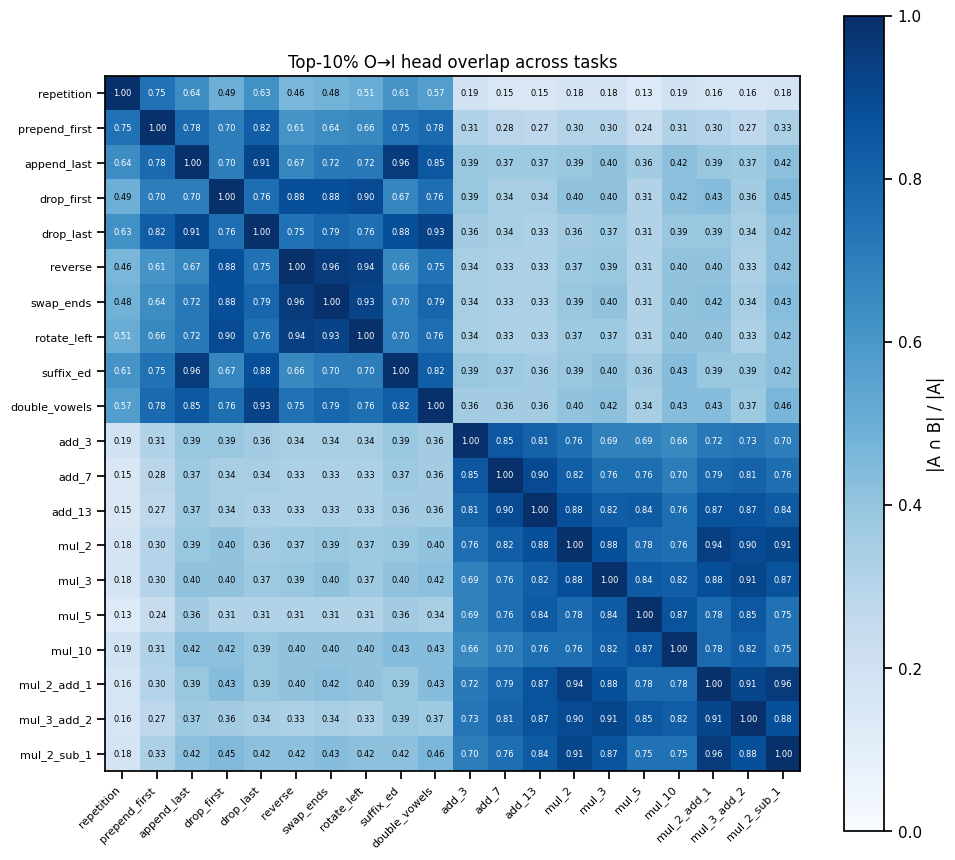

In [17]:
names_act = TASK_NAMES_ACTIVE
nt = len(names_act)
overlap_mat = np.zeros((nt, nt))
for i, n1 in enumerate(names_act):
    for j, n2 in enumerate(names_act):
        s1 = set(task_top_heads[n1]); s2 = set(task_top_heads[n2])
        overlap_mat[i, j] = len(s1 & s2) / max(len(s1), 1)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(overlap_mat, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='|A \u2229 B| / |A|')
ax.set_xticks(range(nt)); ax.set_yticks(range(nt))
ax.set_xticklabels(names_act, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(names_act, fontsize=8)
for i in range(nt):
    for j in range(nt):
        ax.text(j, i, f'{overlap_mat[i,j]:.2f}', ha='center', va='center',
                color='white' if overlap_mat[i,j] > 0.5 else 'black', fontsize=6)
ax.set_title('Top-10% O→I head overlap across tasks')
plt.tight_layout(); plt.show()

## Cross-task ablation

Ablate task B's top-10% heads, measure accuracy on task A's prompts.
Tests whether the same heads mediate ICL across tasks.

In [22]:
# --- Cross-task ablation: ablate task B's heads, measure accuracy on task A's prompts ---
# Result[row=A, col=B] = accuracy on A's prompts when B's top-10% heads are ablated

print("Running cross-task ablation...")
cross_abl_acc = np.zeros((len(TASK_NAMES_ACTIVE), len(TASK_NAMES_ACTIVE)))

for col_j, col_name in enumerate(TASK_NAMES_ACTIVE):
    # Build ablation hooks from col_name's head set
    col_hooks = make_ablation_hooks(heads_by_layer(task_top_heads[col_name]))
    for row_i, row_name in enumerate(TASK_NAMES_ACTIVE):
        correct = []
        for pdata in TASKS[row_name]:
            tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
            correct.append(check_correct_multitoken(
                model, tokens, pdata['query_output'], hooks=col_hooks))
            torch.cuda.empty_cache()
        cross_abl_acc[row_i, col_j] = np.mean(correct)
    print(f'  ablating {col_name} heads: done')

print('Cross-task ablation complete')

Running cross-task ablation...
  ablating repetition heads: done
  ablating prepend_first heads: done
  ablating append_last heads: done
  ablating drop_first heads: done
  ablating drop_last heads: done
  ablating reverse heads: done
  ablating swap_ends heads: done
  ablating rotate_left heads: done
  ablating suffix_ed heads: done
  ablating double_vowels heads: done
  ablating add_3 heads: done
  ablating add_7 heads: done
  ablating add_13 heads: done
  ablating mul_2 heads: done
  ablating mul_3 heads: done
  ablating mul_5 heads: done
  ablating mul_10 heads: done
  ablating mul_2_add_1 heads: done
  ablating mul_3_add_2 heads: done
  ablating mul_2_sub_1 heads: done
Cross-task ablation complete


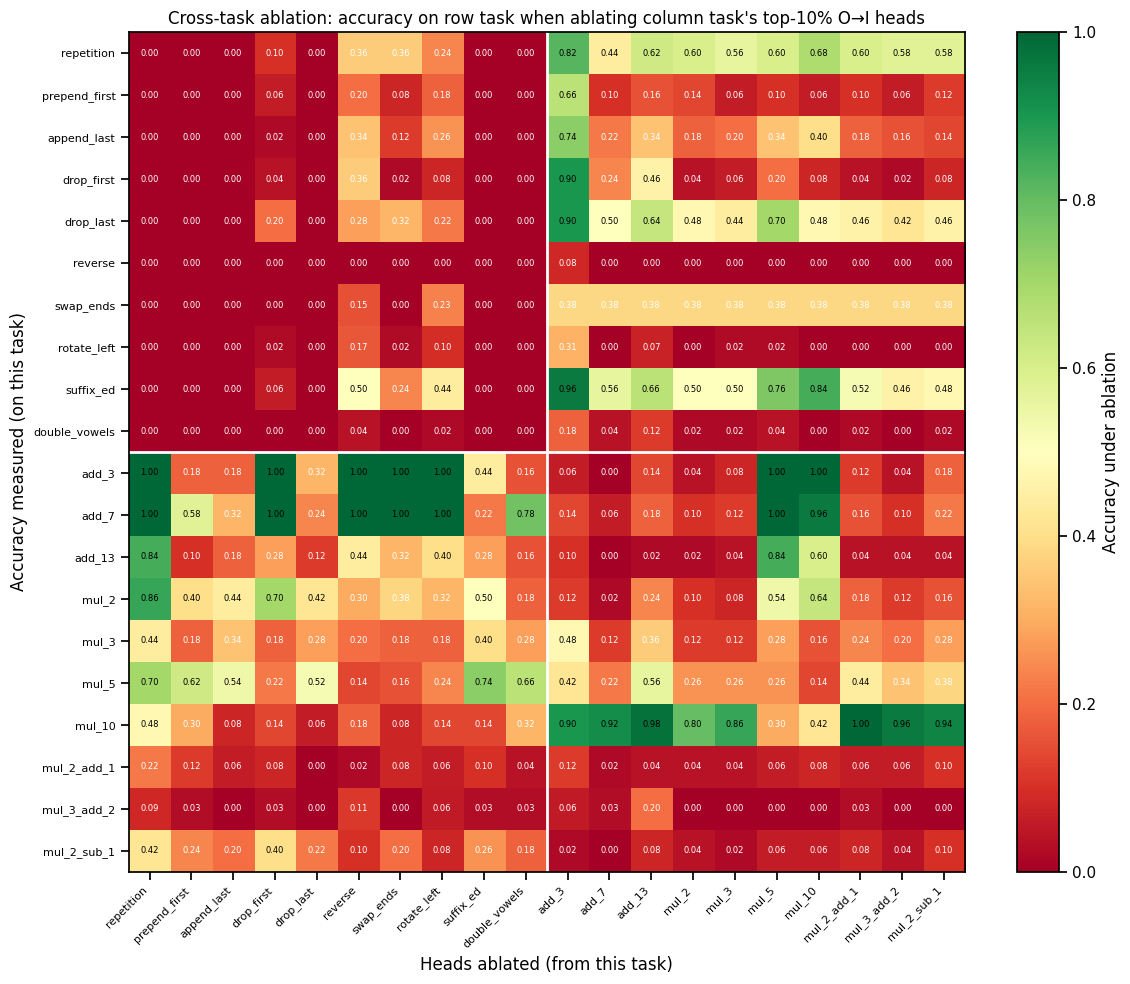


Block summary (mean accuracy under cross-task ablation):
  nonce→nonce (off-diag)        : 0.063 ± 0.119
  arith→arith (off-diag)        : 0.262 ± 0.311
  nonce heads on arith          : 0.336 ± 0.295
  arith heads on nonce          : 0.292 ± 0.266


In [23]:
# --- Plot: cross-task ablation heatmap ---
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cross_abl_acc, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Accuracy under ablation')
nt = len(TASK_NAMES_ACTIVE)
ax.set_xticks(range(nt)); ax.set_yticks(range(nt))
ax.set_xticklabels(TASK_NAMES_ACTIVE, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(TASK_NAMES_ACTIVE, fontsize=8)
ax.set_xlabel('Heads ablated (from this task)')
ax.set_ylabel('Accuracy measured (on this task)')
for i in range(nt):
    for j in range(nt):
        ax.text(j, i, f'{cross_abl_acc[i,j]:.2f}', ha='center', va='center',
                fontsize=6, color='white' if cross_abl_acc[i,j] < 0.4 else 'black')
ax.set_title('Cross-task ablation: accuracy on row task when ablating column task\'s top-10% O→I heads')

# Add block boundary lines between nonce and arithmetic
n_nonce_active = sum(1 for n in NONCE_TASKS if n in TASK_NAMES_ACTIVE)
ax.axhline(n_nonce_active - 0.5, color='white', lw=2)
ax.axvline(n_nonce_active - 0.5, color='white', lw=2)

plt.tight_layout(); plt.show()

# Print summary: mean accuracy within and across blocks
nonce_active = [n for n in NONCE_TASKS if n in TASK_NAMES_ACTIVE]
arith_active = [n for n in ARITH_TASKS if n in TASK_NAMES_ACTIVE]
ni = [TASK_NAMES_ACTIVE.index(n) for n in nonce_active]
ai = [TASK_NAMES_ACTIVE.index(n) for n in arith_active]

blocks = {
    'nonce→nonce (off-diag)': [cross_abl_acc[i,j] for i in ni for j in ni if i != j],
    'arith→arith (off-diag)': [cross_abl_acc[i,j] for i in ai for j in ai if i != j],
    'nonce heads on arith':   [cross_abl_acc[i,j] for i in ai for j in ni],
    'arith heads on nonce':   [cross_abl_acc[i,j] for i in ni for j in ai],
}
print('\nBlock summary (mean accuracy under cross-task ablation):')
for label, vals in blocks.items():
    if vals:
        print(f'  {label:<30s}: {np.mean(vals):.3f} ± {np.std(vals):.3f}')

## Pooled cross-category ablation

Score O→I heads pooled across all nonce tasks and all arith tasks.
Then ablate each set (and subsets: overlap, only-nonce, only-arith) and measure accuracy on both categories.

In [31]:
# === Pool O→I scores across task categories, then cross-ablate ===

# Step 1: Compute pooled scores across all nonce and all arith tasks
nonce_active = [n for n in NONCE_TASKS if n in TASK_NAMES_ACTIVE]
arith_active = [n for n in ARITH_TASKS if n in TASK_NAMES_ACTIVE]

def score_heads_pooled(task_names):
    """Score heads using prompts from ALL tasks in the list, averaged together."""
    num_sum  = np.zeros((n_layers, n_heads), dtype=np.float64)
    base_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
    cnt = 0
    for name in task_names:
        for pdata in tqdm(TASKS[name], desc=name, leave=False):
            demos = pdata['demo_pairs']
            tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
            seq_len = tokens.shape[1]
            per_demo = find_per_demo_positions(model, pdata['prompt'], demos)
            all_in = set(); all_out = set()
            for d in per_demo:
                for p in d.get('input_positions', []):  all_in.add(p)
                for p in d.get('output_positions', []): all_out.add(p)
            num_mask = torch.zeros(seq_len, seq_len)
            for d in per_demo:
                for op in d.get('output_positions', []):
                    for ip in d.get('input_positions', []):
                        num_mask[op, ip] = 1.0
            base_mask = torch.zeros(seq_len, seq_len)
            ins_list = sorted(all_in)
            for q in range(seq_len):
                if q in all_out: continue
                for ik in ins_list:
                    if ik <= q: base_mask[q, ik] = 1.0
            n_num = int(num_mask.sum().item()); n_base = int(base_mask.sum().item())
            if n_num == 0 or n_base == 0: continue
            with torch.no_grad():
                _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
            for L in range(n_layers):
                patt = cache['pattern', L][0].cpu().float()
                num_sum[L, :]  += (patt * num_mask).sum(dim=(1, 2)).numpy() / n_num
                base_sum[L, :] += (patt * base_mask).sum(dim=(1, 2)).numpy() / n_base
            cnt += 1
            del cache; torch.cuda.empty_cache()
    return (num_sum - base_sum) / max(cnt, 1)

print('Scoring pooled nonce heads...')
nonce_pooled_scores = score_heads_pooled(nonce_active)
print('Scoring pooled arith heads...')
arith_pooled_scores = score_heads_pooled(arith_active)

# Select top 10%
flat_nonce = sorted([(L, h, nonce_pooled_scores[L, h])
                     for L in range(n_layers) for h in range(n_heads)], key=lambda x: -x[2])
flat_arith = sorted([(L, h, arith_pooled_scores[L, h])
                     for L in range(n_layers) for h in range(n_heads)], key=lambda x: -x[2])

H_nonce = set((L, h) for L, h, _ in flat_nonce[:top10pct_n])
H_arith = set((L, h) for L, h, _ in flat_arith[:top10pct_n])
H_overlap    = H_nonce & H_arith
H_only_nonce = H_nonce - H_arith
H_only_arith = H_arith - H_nonce

print(f'\nH_nonce: {len(H_nonce)} heads')
print(f'H_arith: {len(H_arith)} heads')
print(f'Overlap: {len(H_overlap)} ({100*len(H_overlap)/len(H_nonce):.1f}%)')
print(f'Only nonce: {len(H_only_nonce)}')
print(f'Only arith: {len(H_only_arith)}')

# Build head sets and hooks
rng_ctrl = random.Random(999)
all_pairs_set = set(all_pairs)
rand_ctrl = rng_ctrl.sample(list(all_pairs_set - H_nonce - H_arith), top10pct_n)

head_sets = {
    'H_nonce':      list(H_nonce),
    'H_arith':      list(H_arith),
    'Overlap':      list(H_overlap),
    'Only nonce':   list(H_only_nonce),
    'Only arith':   list(H_only_arith),
}
head_set_hooks = {k: make_ablation_hooks(heads_by_layer(v)) for k, v in head_sets.items()}
rand_hooks = {k: make_ablation_hooks(heads_by_layer(
    rng_ctrl.sample(list(all_pairs_set - set(v)), len(v)))) for k, v in head_sets.items()}


Scoring pooled nonce heads...


Scoring pooled arith heads...



H_nonce: 67 heads
H_arith: 67 heads
Overlap: 26 (38.8%)
Only nonce: 41
Only arith: 41


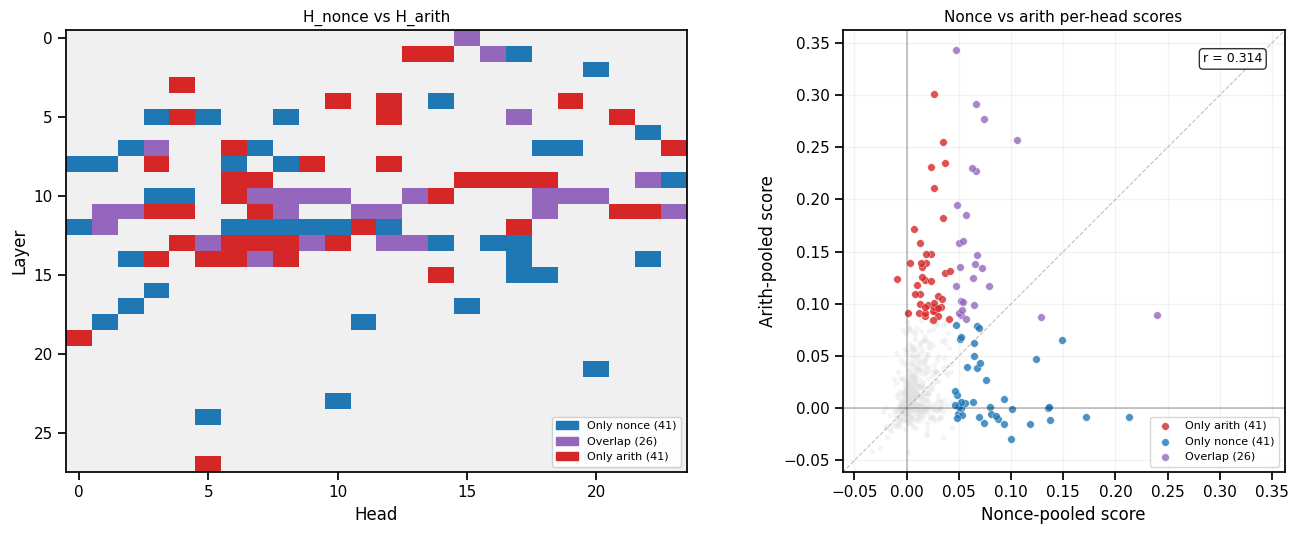

In [53]:
# === Plot 1: H_nonce vs H_arith ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

na_cats = ['Unselected', 'Only nonce', 'Overlap', 'Only arith']
na_colors = {'Unselected': '#f0f0f0', 'Only nonce': 'tab:blue',
             'Overlap': 'tab:purple', 'Only arith': 'tab:red'}
na_int = {c: i for i, c in enumerate(na_cats)}
na_counts = {c: sum(1 for v in cat_map.values() if v == c) for c in na_cats}

ax = axes[0]
grid_na = np.zeros((n_layers, n_heads))
for (L, h), cat in cat_map.items():
    grid_na[L, h] = na_int[cat]
cmap_na = ListedColormap([na_colors[c] for c in na_cats])
norm_na = BoundaryNorm(np.arange(-0.5, len(na_cats)), cmap_na.N)
ax.imshow(grid_na, aspect='auto', cmap=cmap_na, norm=norm_na)
ax.set_xlabel('Head'); ax.set_ylabel('Layer')
ax.set_title('H_nonce vs H_arith', fontsize=11)
ax.legend(handles=[Patch(color=na_colors[c], label=f'{c} ({na_counts[c]})')
                   for c in na_cats if c != 'Unselected' and na_counts[c] > 0],
          fontsize=8, loc='lower right', framealpha=0.9)

ax = axes[1]
for cat in ['Unselected', 'Only arith', 'Only nonce', 'Overlap']:
    ns = [nonce_pooled_scores[L, h] for L in range(n_layers) for h in range(n_heads)
          if cat_map[(L, h)] == cat]
    as_ = [arith_pooled_scores[L, h] for L in range(n_layers) for h in range(n_heads)
           if cat_map[(L, h)] == cat]
    if cat == 'Unselected':
        ax.scatter(ns, as_, c='#e0e0e0', s=8, alpha=0.25, zorder=1)
    else:
        ax.scatter(ns, as_, c=na_colors[cat], s=30, alpha=0.8, label=f'{cat} ({na_counts[cat]})',
                   edgecolors='white', linewidths=0.3, zorder=2)
ax.set_xlabel('Nonce-pooled score'); ax.set_ylabel('Arith-pooled score')
ax.set_title('Nonce vs arith per-head scores', fontsize=11)
ax.axhline(0, color='black', lw=0.3); ax.axvline(0, color='black', lw=0.3)
lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([lo, hi], [lo, hi], '--', color='gray', lw=0.8, alpha=0.5)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_aspect('equal'); ax.legend(fontsize=8); ax.grid(True, alpha=0.15)
r = np.corrcoef(
    [nonce_pooled_scores[L, h] for L in range(n_layers) for h in range(n_heads)],
    [arith_pooled_scores[L, h] for L in range(n_layers) for h in range(n_heads)]
)[0, 1]
ax.text(0.95, 0.95, f'r = {r:.3f}', transform=ax.transAxes, fontsize=9,
        ha='right', va='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

plt.tight_layout(); plt.show()

In [32]:
# Step 2: Evaluate cross-ablation on pooled nonce and arith prompts
SET_NAMES = list(head_sets.keys())

# Collect all nonce and arith prompts
nonce_prompts = [(name, pdata) for name in nonce_active for pdata in TASKS[name]]
arith_prompts = [(name, pdata) for name in arith_active for pdata in TASKS[name]]

def eval_on_prompts(prompts, hooks, desc=''):
    accs, ranks = [], []
    for name, pdata in tqdm(prompts, desc=desc, leave=False):
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        ans = pdata['query_output']
        h = hooks if hooks else None
        accs.append(check_correct_multitoken(model, tokens, ans, hooks=h))
        ranks.append(first_content_token_rank(model, tokens, ans, hooks=h))
        torch.cuda.empty_cache()
    return np.array(accs), np.array(ranks)

# Unablated baselines
print('Unablated baselines...')
nonce_base_acc, nonce_base_rank = eval_on_prompts(nonce_prompts, None, 'nonce unablated')
arith_base_acc, arith_base_rank = eval_on_prompts(arith_prompts, None, 'arith unablated')
print(f'  Nonce unablated: acc={nonce_base_acc.mean():.3f}, rank={np.median(nonce_base_rank):.1f}')
print(f'  Arith unablated: acc={arith_base_acc.mean():.3f}, rank={np.median(arith_base_rank):.1f}')

# Treatment and matched-random for each head set
results = {}
for sname in SET_NAMES:
    print(f'\nEvaluating {sname} ({len(head_sets[sname])} heads)...')
    results[sname] = {}
    # On nonce
    t_acc, t_rank = eval_on_prompts(nonce_prompts, head_set_hooks[sname], f'nonce/{sname}')
    r_acc, r_rank = eval_on_prompts(nonce_prompts, rand_hooks[sname], f'nonce/{sname} rand')
    results[sname]['nonce'] = {'treat_acc': t_acc, 'treat_rank': t_rank,
                                'rand_acc': r_acc, 'rand_rank': r_rank}
    print(f'  on nonce: treat_acc={t_acc.mean():.3f}, rand_acc={r_acc.mean():.3f}')
    # On arith
    t_acc, t_rank = eval_on_prompts(arith_prompts, head_set_hooks[sname], f'arith/{sname}')
    r_acc, r_rank = eval_on_prompts(arith_prompts, rand_hooks[sname], f'arith/{sname} rand')
    results[sname]['arith'] = {'treat_acc': t_acc, 'treat_rank': t_rank,
                                'rand_acc': r_acc, 'rand_rank': r_rank}
    print(f'  on arith: treat_acc={t_acc.mean():.3f}, rand_acc={r_acc.mean():.3f}')

print('\nDone')


Unablated baselines...


  Nonce unablated: acc=1.000, rank=0.0
  Arith unablated: acc=1.000, rank=0.0

Evaluating H_nonce (67 heads)...


  on nonce: treat_acc=0.000, rand_acc=0.621


  on arith: treat_acc=0.204, rand_acc=0.680

Evaluating H_arith (67 heads)...


  on nonce: treat_acc=0.326, rand_acc=0.487


...

  on arith: treat_acc=0.588, rand_acc=0.841

Evaluating Only nonce (41 heads)...


  on nonce: treat_acc=0.010, rand_acc=0.777


  on arith: treat_acc=0.753, rand_acc=0.777

Evaluating Only arith (41 heads)...


  on nonce: treat_acc=0.463, rand_acc=0.496


  on arith: treat_acc=0.664, rand_acc=0.730

Done


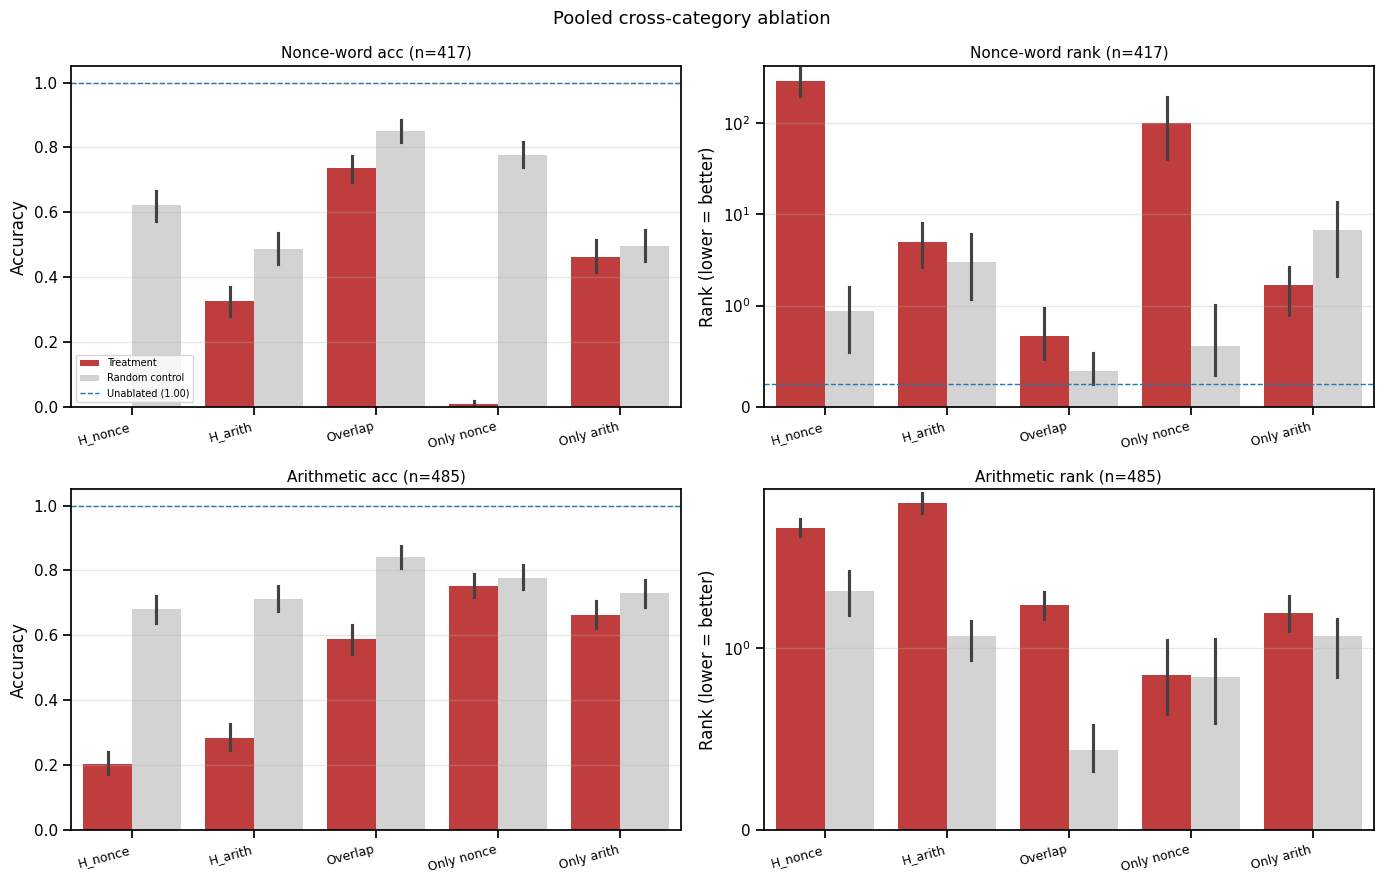

In [35]:
# --- Pooled cross-category ablation (cleaned up) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row, (eval_cat, base_acc, base_rank, n_prompts, cat_label) in enumerate([
    ('nonce', nonce_base_acc, nonce_base_rank, len(nonce_prompts), 'Nonce-word'),
    ('arith', arith_base_acc, arith_base_rank, len(arith_prompts), 'Arithmetic'),
]):
    for col, (metric, base_vals, ylabel) in enumerate([
        ('acc', base_acc, 'Accuracy'),
        ('rank', base_rank, 'Rank (lower = better)'),
    ]):
        ax = axes[row, col]
        rows = []
        for sname in ['H_nonce', 'H_arith', 'Overlap', 'Only nonce', 'Only arith']:
            for v in results[sname][eval_cat][f'treat_{metric}']:
                rows.append({'Head set': sname, 'Type': 'Treatment', 'value': v})
            for v in results[sname][eval_cat][f'rand_{metric}']:
                rows.append({'Head set': sname, 'Type': 'Random control', 'value': v})
        df = pd.DataFrame(rows)
        sns.barplot(data=df, x='Head set', y='value', hue='Type',
                    hue_order=['Treatment', 'Random control'],
                    palette={'Treatment': 'tab:red', 'Random control': 'lightgray'},
                    errorbar=('ci', 95), linewidth=0, ax=ax)
        ax.axhline(np.mean(base_vals), color='tab:blue', ls='--', lw=1,
                   label=f'Unablated ({np.mean(base_vals):.2f})')
        ax.set_xlabel(''); ax.set_ylabel(ylabel)
        ax.set_title(f'{cat_label} {metric} (n={n_prompts})', fontsize=11)
        ax.grid(True, alpha=0.3, axis='y')
        plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)
        if metric == 'rank':
            ax.set_yscale('symlog', linthresh=1)
        else:
            ax.set_ylim(0, 1.05)
        if row == 0 and col == 0:
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles, labels, fontsize=7, loc='lower left')
        else:
            ax.get_legend().remove()

fig.suptitle('Pooled cross-category ablation', fontsize=13)
plt.tight_layout(); plt.show()

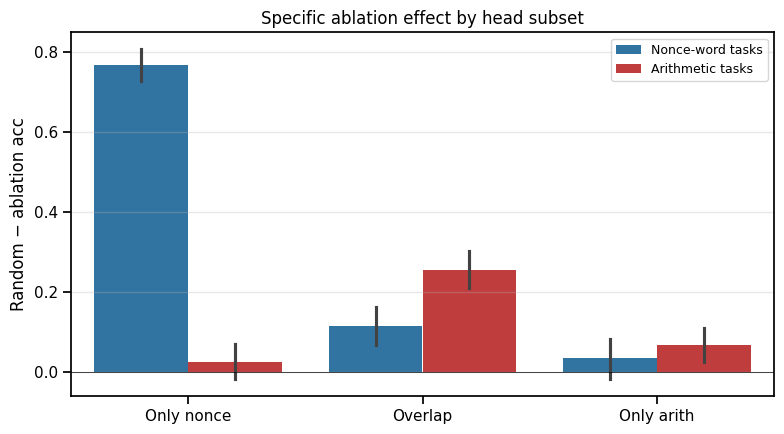


Head set       n_heads   Nonce effect   Arith effect
----------------------------------------------------
Only nonce          41         +0.767         +0.025
Overlap             26         +0.115         +0.254
Only arith          41         +0.034         +0.066


In [52]:
# --- Specific effect plot (cleaned up) ---
subset_names = ['Only nonce', 'Overlap', 'Only arith']
rows = []
for sname in subset_names:
    for ecat, elabel in [('nonce', 'Nonce-word tasks'), ('arith', 'Arithmetic tasks')]:
        t = results[sname][ecat]['treat_acc']
        r = results[sname][ecat]['rand_acc']
        for tv, rv in zip(t, r):
            rows.append({'Head set': sname, 'Evaluated on': elabel, 'effect': rv - tv})
df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=df, x='Head set', y='effect', hue='Evaluated on',
            palette={'Nonce-word tasks': 'tab:blue', 'Arithmetic tasks': 'tab:red'},
            errorbar=('ci', 95), linewidth=0, ax=ax)
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('Random − ablation acc')
ax.set_xlabel('')
ax.set_title('Specific ablation effect by head subset', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=9)

# # Annotate
# for container_idx, (ecat, elabel) in enumerate(
#         [('nonce', 'Nonce-word tasks'), ('arith', 'Arithmetic tasks')]):
#     for bar_idx, sname in enumerate(subset_names):
#         t = results[sname][ecat]['treat_acc']
#         r = results[sname][ecat]['rand_acc']
#         effect = np.mean(r) - np.mean(t)
#         bar = ax.containers[container_idx][bar_idx]
#         ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
#                 f'{effect:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout(); plt.show()

print(f'\n{"Head set":<14s} {"n_heads":>7s}  {"Nonce effect":>13s}  {"Arith effect":>13s}')
print('-' * 52)
for sname in subset_names:
    n = len(head_sets[sname])
    e_n = np.mean(results[sname]['nonce']['rand_acc']) - np.mean(results[sname]['nonce']['treat_acc'])
    e_a = np.mean(results[sname]['arith']['rand_acc']) - np.mean(results[sname]['arith']['treat_acc'])
    print(f'{sname:<14s} {n:>7d}  {e_n:>+13.3f}  {e_a:>+13.3f}')

## Pooled all-tasks

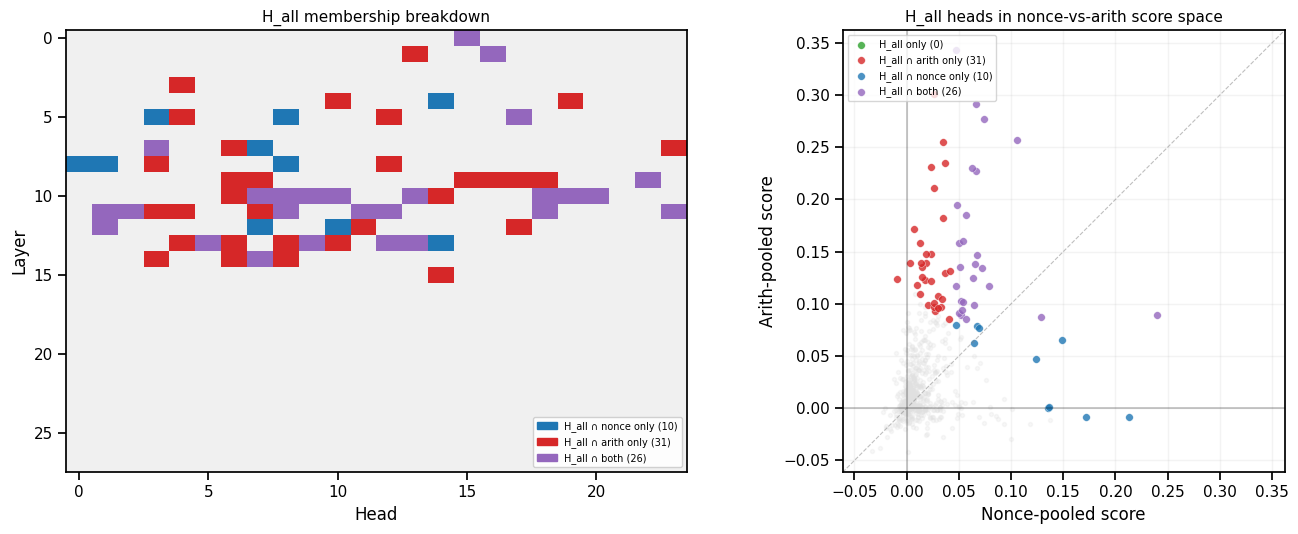


H_all composition:
  H_all ∩ nonce only       : 10
  H_all ∩ arith only       : 31
  H_all ∩ both             : 26
  Total H_all: 67


In [59]:
# === Plot 2: H_all breakdown ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

all_cats = ['Unselected', 'H_all only', 'H_all ∩ nonce only',
            'H_all ∩ arith only', 'H_all ∩ both']
all_colors = {'Unselected': '#f0f0f0', 'H_all only': 'tab:green',
              'H_all ∩ nonce only': 'tab:blue', 'H_all ∩ arith only': 'tab:red',
              'H_all ∩ both': 'tab:purple'}
all_int = {c: i for i, c in enumerate(all_cats)}

all_cat_map = {}
for L in range(n_layers):
    for h in range(n_heads):
        p = (L, h)
        if p not in H_all:
            all_cat_map[p] = 'Unselected'
        elif p in H_nonce and p in H_arith:
            all_cat_map[p] = 'H_all ∩ both'
        elif p in H_nonce:
            all_cat_map[p] = 'H_all ∩ nonce only'
        elif p in H_arith:
            all_cat_map[p] = 'H_all ∩ arith only'
        else:
            all_cat_map[p] = 'H_all only'

all_counts = {c: sum(1 for v in all_cat_map.values() if v == c) for c in all_cats}

ax = axes[0]
grid_all = np.zeros((n_layers, n_heads))
for (L, h), cat in all_cat_map.items():
    grid_all[L, h] = all_int[cat]
cmap_all = ListedColormap([all_colors[c] for c in all_cats])
norm_all = BoundaryNorm(np.arange(-0.5, len(all_cats)), cmap_all.N)
ax.imshow(grid_all, aspect='auto', cmap=cmap_all, norm=norm_all)
ax.set_xlabel('Head'); ax.set_ylabel('Layer')
ax.set_title('H_all membership breakdown', fontsize=11)
ax.legend(handles=[Patch(color=all_colors[c], label=f'{c} ({all_counts[c]})')
                   for c in all_cats if c != 'Unselected' and all_counts[c] > 0],
          fontsize=7, loc='lower right', framealpha=0.9)

ax = axes[1]
for cat in ['Unselected', 'H_all only', 'H_all ∩ arith only',
            'H_all ∩ nonce only', 'H_all ∩ both']:
    ns = [nonce_pooled_scores[L, h] for L in range(n_layers) for h in range(n_heads)
          if all_cat_map[(L, h)] == cat]
    as_ = [arith_pooled_scores[L, h] for L in range(n_layers) for h in range(n_heads)
           if all_cat_map[(L, h)] == cat]
    if cat == 'Unselected':
        ax.scatter(ns, as_, c='#e0e0e0', s=8, alpha=0.25, zorder=1)
    else:
        ax.scatter(ns, as_, c=all_colors[cat], s=30, alpha=0.8,
                   label=f'{cat} ({all_counts[cat]})',
                   edgecolors='white', linewidths=0.3, zorder=2)
ax.set_xlabel('Nonce-pooled score'); ax.set_ylabel('Arith-pooled score')
ax.set_title('H_all heads in nonce-vs-arith score space', fontsize=11)
ax.axhline(0, color='black', lw=0.3); ax.axvline(0, color='black', lw=0.3)
ax.plot([lo, hi], [lo, hi], '--', color='gray', lw=0.8, alpha=0.5)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_aspect('equal'); ax.legend(fontsize=7, loc='upper left'); ax.grid(True, alpha=0.15)

plt.tight_layout(); plt.show()

print(f'\nH_all composition:')
for c in all_cats:
    if c != 'Unselected' and all_counts[c] > 0:
        print(f'  {c:<25s}: {all_counts[c]}')
print(f'  Total H_all: {len(H_all)}')

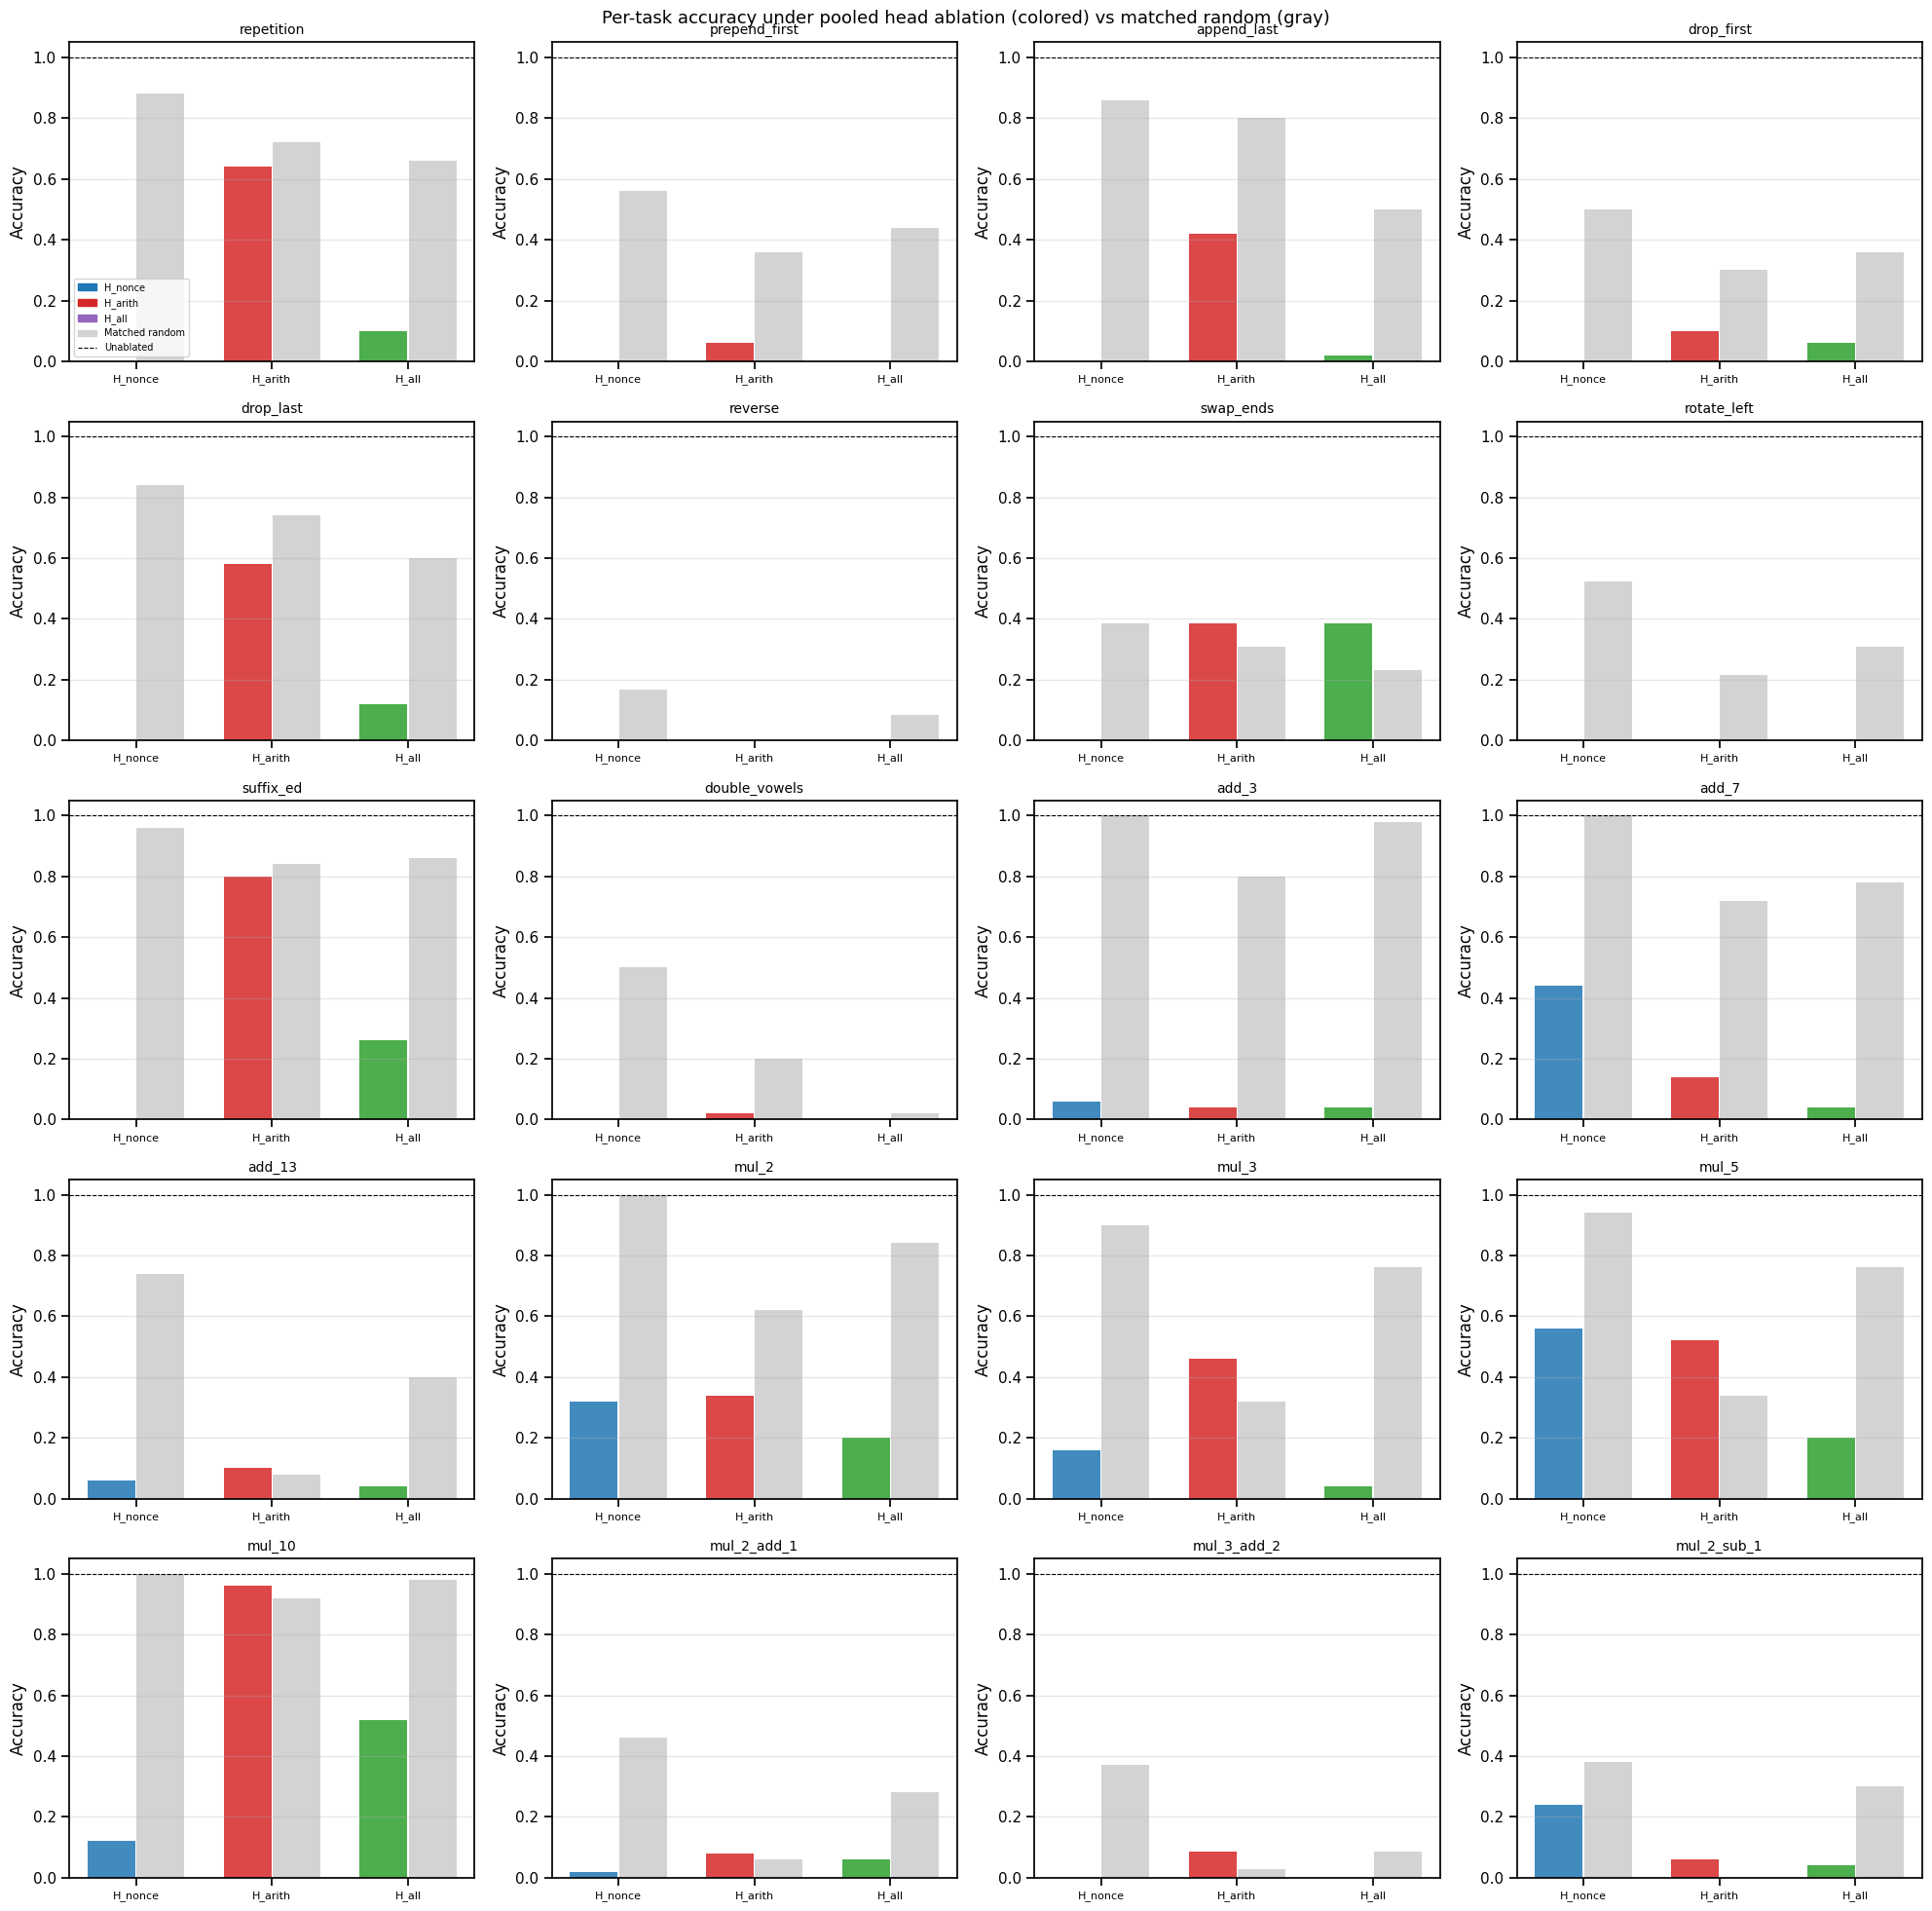

In [58]:
# === Per-task accuracy under H_nonce / H_arith / H_all ablation with controls ===

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

ablation_sets = ['H_nonce', 'H_arith', 'H_all']
set_colors = {'H_nonce': 'tab:blue', 'H_arith': 'tab:red', 'H_all': 'tab:green'}

for ax, name in zip(axes, TASK_NAMES_ACTIVE):
    x = np.arange(len(ablation_sets))
    treat_vals = [pooled_per_task_acc[s][name] for s in ablation_sets]
    rand_vals = [pooled_per_task_rand[s][name] for s in ablation_sets]
    baseline = unablated_per_task[name]

    ax.bar(x - 0.18, treat_vals, 0.35,
           color=[set_colors[s] for s in ablation_sets], alpha=0.85)
    ax.bar(x + 0.18, rand_vals, 0.35, color='lightgray')
    ax.axhline(baseline, color='black', ls='--', lw=0.8, label=f'Unablated ({baseline:.2f})')

    ax.set_xticks(x)
    ax.set_xticklabels(ablation_sets, fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Accuracy')
    ax.set_title(name, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # # Annotate treatment values
    # for i, v in enumerate(treat_vals):
    #     ax.text(x[i] - 0.18, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=7)

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='tab:blue', label='H_nonce'),
    Patch(color='tab:red', label='H_arith'),
    Patch(color='tab:purple', label='H_all'),
    Patch(color='lightgray', label='Matched random'),
    plt.Line2D([0], [0], color='black', ls='--', lw=0.8, label='Unablated'),
], fontsize=7, loc='lower left')

for ax in axes[len(TASK_NAMES_ACTIVE):]:
    ax.set_visible(False)

fig.suptitle('Per-task accuracy under pooled head ablation (colored) vs matched random (gray)',
             fontsize=13)
plt.tight_layout(); plt.show()

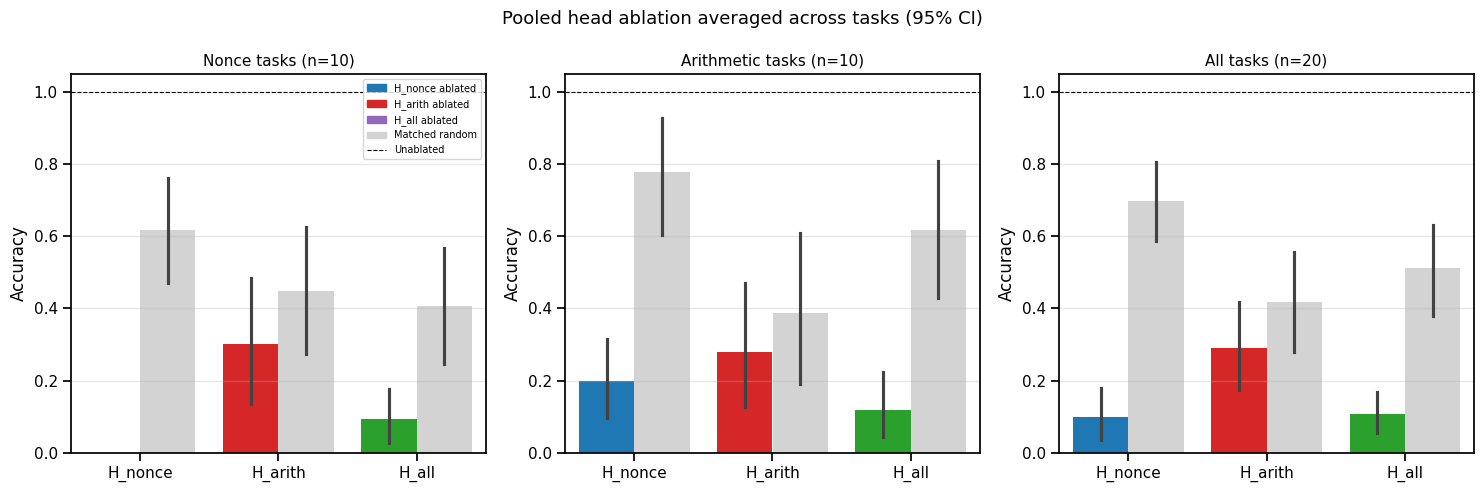

In [64]:
# === Averaged pooled ablation: by category and overall (seaborn) ===

ablation_sets = ['H_nonce', 'H_arith', 'H_all']
groups = {
    'Nonce tasks': nonce_active,
    'Arithmetic tasks': arith_active,
    'All tasks': TASK_NAMES_ACTIVE,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (group_label, task_list) in zip(axes, groups.items()):
    rows = []
    for s in ablation_sets:
        for name in task_list:
            rows.append({'Head set': s, 'Type': 'Treatment',
                         'Accuracy': pooled_per_task_acc[s][name]})
            rows.append({'Head set': s, 'Type': 'Random control',
                         'Accuracy': pooled_per_task_rand[s][name]})
    df = pd.DataFrame(rows)

    sns.barplot(data=df, x='Head set', y='Accuracy', hue='Type',
                hue_order=['Treatment', 'Random control'],
                palette={'Treatment': 'tab:blue', 'Random control': 'lightgray'},
                errorbar=('ci', 95), linewidth=0, ax=ax)

    # Color treatment bars individually
    n_sets = len(ablation_sets)
    set_colors = ['tab:blue', 'tab:red', 'tab:green']
    for i, bar in enumerate(ax.containers[0]):
        bar.set_facecolor(set_colors[i])

    baseline_vals = [unablated_per_task[name] for name in task_list]
    ax.axhline(np.mean(baseline_vals), color='black', ls='--', lw=0.8)

    ax.set_ylim(0, 1.05)
    ax.set_xlabel(''); ax.set_ylabel('Accuracy')
    ax.set_title(f'{group_label} (n={len(task_list)})', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.get_legend().remove()

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='tab:blue', label='H_nonce ablated'),
    Patch(color='tab:red', label='H_arith ablated'),
    Patch(color='tab:purple', label='H_all ablated'),
    Patch(color='lightgray', label='Matched random'),
    plt.Line2D([0], [0], color='black', ls='--', lw=0.8, label='Unablated'),
], fontsize=7, loc='upper right')

fig.suptitle('Pooled head ablation averaged across tasks (95% CI)', fontsize=13)
plt.tight_layout(); plt.show()

## Extended cross-task ablation heatmap

Add pooled head sets (H_nonce, H_arith, H_all) as columns and pooled evaluation sets (ALL nonce, ALL arith, ALL tasks) as rows.

In [37]:
# === Compute H_all (pooled across ALL tasks) and build extended heatmap ===

print('Scoring heads pooled across ALL tasks...')
all_pooled_scores = score_heads_pooled(TASK_NAMES_ACTIVE)
flat_all = sorted([(L, h, all_pooled_scores[L, h])
                   for L in range(n_layers) for h in range(n_heads)], key=lambda x: -x[2])
H_all = set((L, h) for L, h, _ in flat_all[:top10pct_n])

print(f'H_all: {len(H_all)} heads')
print(f'H_all & H_nonce: {len(H_all & H_nonce)}')
print(f'H_all & H_arith: {len(H_all & H_arith)}')
print(f'H_all & H_nonce & H_arith: {len(H_all & H_nonce & H_arith)}')

# Build hooks for pooled sets
pooled_names = ['H_nonce', 'H_arith', 'H_all']
pooled_heads = {'H_nonce': list(H_nonce), 'H_arith': list(H_arith), 'H_all': list(H_all)}
pooled_hooks = {k: make_ablation_hooks(heads_by_layer(v)) for k, v in pooled_heads.items()}

# Extended heatmap: per-task rows + pooled rows, per-task cols + pooled cols
ext_row_names = TASK_NAMES_ACTIVE + ['ALL nonce', 'ALL arith', 'ALL tasks']
ext_col_names = TASK_NAMES_ACTIVE + pooled_names

# Gather prompts for pooled row evaluations
pooled_prompts = {
    'ALL nonce': [(n, p) for n in nonce_active for p in TASKS[n]],
    'ALL arith': [(n, p) for n in arith_active for p in TASKS[n]],
    'ALL tasks': [(n, p) for n in TASK_NAMES_ACTIVE for p in TASKS[n]],
}

# Compute the full extended heatmap
ext_acc = np.zeros((len(ext_row_names), len(ext_col_names)))

for cj, col_name in enumerate(ext_col_names):
    if col_name in pooled_hooks:
        hooks = pooled_hooks[col_name]
    else:
        hooks = task_ablation_hooks[col_name]['top10']

    # Per-task rows: reuse cross_abl_acc for per-task cols
    for ri, row_name in enumerate(TASK_NAMES_ACTIVE):
        if col_name in TASK_NAMES_ACTIVE:
            ci_old = TASK_NAMES_ACTIVE.index(col_name)
            ext_acc[ri, cj] = cross_abl_acc[ri, ci_old]
        else:
            correct = []
            for pdata in TASKS[row_name]:
                tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
                correct.append(check_correct_multitoken(model, tokens,
                               pdata['query_output'], hooks=hooks))
                torch.cuda.empty_cache()
            ext_acc[ri, cj] = np.mean(correct)

    # Pooled rows
    for ri_off, pool_name in enumerate(['ALL nonce', 'ALL arith', 'ALL tasks']):
        ri = len(TASK_NAMES_ACTIVE) + ri_off
        correct = []
        for _, pdata in pooled_prompts[pool_name]:
            tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
            correct.append(check_correct_multitoken(model, tokens,
                           pdata['query_output'], hooks=hooks))
            torch.cuda.empty_cache()
        ext_acc[ri, cj] = np.mean(correct)

    print(f'  col {col_name}: done')

print('Extended heatmap complete')


Scoring heads pooled across ALL tasks...


H_all: 67 heads
H_all & H_nonce: 36
H_all & H_arith: 57
H_all & H_nonce & H_arith: 26
  col repetition: done
  col prepend_first: done
  col append_last: done
  col drop_first: done
  col drop_last: done
  col reverse: done
  col swap_ends: done
  col rotate_left: done
  col suffix_ed: done
  col double_vowels: done
  col add_3: done
  col add_7: done
  col add_13: done
  col mul_2: done
  col mul_3: done
  col mul_5: done
  col mul_10: done
  col mul_2_add_1: done
  col mul_3_add_2: done
  col mul_2_sub_1: done
  col H_nonce: done
  col H_arith: done
  col H_all: done
Extended heatmap complete


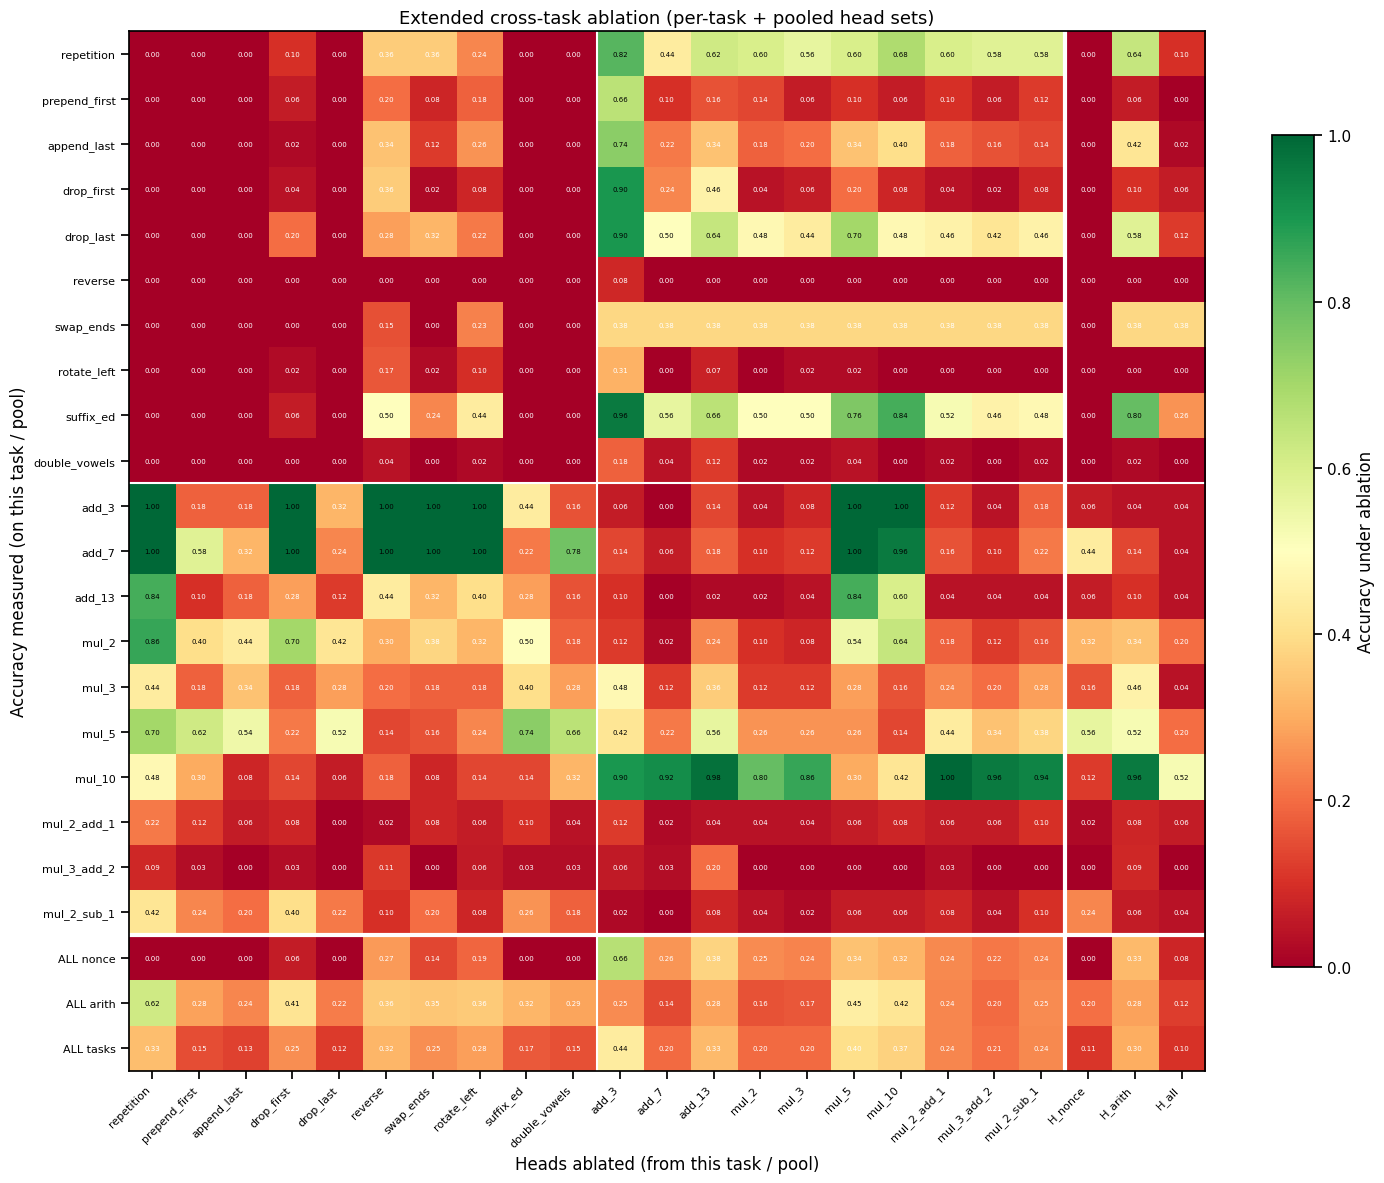

Pooled rows x pooled cols:
               H_nonce   H_arith     H_all
   ALL nonce     0.000     0.326     0.079
   ALL arith     0.204     0.285     0.122
   ALL tasks     0.110     0.304     0.102


In [38]:
# === Plot extended cross-task ablation heatmap ===
n_per_task = len(TASK_NAMES_ACTIVE)
n_ext_rows = len(ext_row_names)
n_ext_cols = len(ext_col_names)

fig, ax = plt.subplots(figsize=(15, 12))
im = ax.imshow(ext_acc, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Accuracy under ablation', shrink=0.8)

ax.set_xticks(range(n_ext_cols)); ax.set_yticks(range(n_ext_rows))
ax.set_xticklabels(ext_col_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ext_row_names, fontsize=8)
ax.set_xlabel('Heads ablated (from this task / pool)')
ax.set_ylabel('Accuracy measured (on this task / pool)')

for i in range(n_ext_rows):
    for j in range(n_ext_cols):
        ax.text(j, i, f'{ext_acc[i,j]:.2f}', ha='center', va='center',
                fontsize=5, color='white' if ext_acc[i,j] < 0.4 else 'black')

# Block boundary lines
n_nonce_a = sum(1 for n in NONCE_TASKS if n in TASK_NAMES_ACTIVE)
ax.axhline(n_nonce_a - 0.5, color='white', lw=1.5)
ax.axhline(n_per_task - 0.5, color='white', lw=3)
ax.axvline(n_nonce_a - 0.5, color='white', lw=1.5)
ax.axvline(n_per_task - 0.5, color='white', lw=3)

ax.set_title('Extended cross-task ablation (per-task + pooled head sets)', fontsize=13)
plt.tight_layout(); plt.show()

# Print the pooled sub-block
print('Pooled rows x pooled cols:')
header = f'{"":>12s}'
for cn in pooled_names:
    header += f'{cn:>10s}'
print(header)
for ri_off, rn in enumerate(['ALL nonce', 'ALL arith', 'ALL tasks']):
    ri = n_per_task + ri_off
    line = f'{rn:>12s}'
    for cj_off in range(len(pooled_names)):
        cj = n_per_task + cj_off
        line += f'{ext_acc[ri, cj]:>10.3f}'
    print(line)


# Task-vector patching experiment

For each task, for each condition:
1. Run ICL prompt under that condition, cache residual at final position at every layer
2. Patch that residual into the zero-shot prompt at each layer
3. Measure first-token rank of correct answer

This produces a (condition × layer) accuracy/rank matrix per task.

In [12]:
PATCH_CONDS = ['orig', 'shuffled_inputs', 'random_inputs', 'star_inputs',
               'shuffled_outputs', 'random_outputs', 'star_outputs']

# Pre-build all condition prompts for the filtered task prompts
task_cond_prompts = {}
for name in TASK_NAMES_ACTIVE:
    rng_p = random.Random(42)
    pools = task_pools[name]
    cond_prompts_list = []
    for pdata in TASKS[name]:
        demos = pdata['demo_pairs']
        qi = pdata['query_input']
        inputs  = [i for i, _ in demos]
        outputs = [o for _, o in demos]
        inp_shuf  = inputs.copy();  rng_p.shuffle(inp_shuf)
        out_shuf  = outputs.copy(); rng_p.shuffle(out_shuf)
        inp_rand  = [rng_p.choice(pools['in_pool'])  for _ in inputs]
        out_rand  = [rng_p.choice(pools['out_pool']) for _ in outputs]
        cp = {
            'orig':              pdata['prompt'],
            'shuffled_inputs':   build_icl_prompt(list(zip(inp_shuf, outputs)), qi),
            'random_inputs':     build_icl_prompt(list(zip(inp_rand, outputs)), qi),
            'star_inputs':       build_icl_prompt([('*', o) for o in outputs], qi),
            'shuffled_outputs':  build_icl_prompt(list(zip(inputs, out_shuf)), qi),
            'random_outputs':    build_icl_prompt(list(zip(inputs, out_rand)), qi),
            'star_outputs':      build_icl_prompt([(i, '*') for i in inputs], qi),
        }
        cond_prompts_list.append(cp)
    task_cond_prompts[name] = cond_prompts_list

In [13]:
# Run the patching experiment (resid_post, held-out queries, multi-token accuracy)
patch_acc  = {name: {c: np.zeros((len(TASKS[name]), n_layers)) for c in PATCH_CONDS}
              for name in TASK_NAMES_ACTIVE}

RESID_POST_FILTER = lambda name: 'resid_post' in name

for name in TASK_NAMES_ACTIVE:
    prompts_list = task_cond_prompts[name]
    gen = TASK_GENERATORS[name]
    rng_ho = random.Random(12345)

    for pi, pdata in enumerate(tqdm(TASKS[name], desc=f'{name} patch')):
        ans_orig = pdata['query_output']
        qi_orig  = pdata['query_input']

        # Generate a held-out query not used in this prompt
        used = set([qi_orig] + [i for i, _ in pdata['demo_pairs']]
                   + [o for _, o in pdata['demo_pairs']])
        for _ in range(100):
            ho_demos, ho_qi, ho_ans = gen(rng_ho)
            if ho_qi not in used:
                break

        zs_prompt = f'{ho_qi} →'
        zs_tokens = model.to_tokens(zs_prompt, prepend_bos=True)
        zs_last = zs_tokens.shape[1] - 1

        for cond in PATCH_CONDS:
            cond_prompt = prompts_list[pi][cond]
            cond_tokens = model.to_tokens(cond_prompt, prepend_bos=True)
            cond_last = cond_tokens.shape[1] - 1
            with torch.no_grad():
                _, cache = model.run_with_cache(cond_tokens, names_filter=RESID_POST_FILTER)
            icl_resids = {L: cache['resid_post', L][0, cond_last].clone()
                          for L in range(n_layers)}
            del cache; torch.cuda.empty_cache()

            for L in range(n_layers):
                replacement = icl_resids[L]
                def patch_hook(resid, hook, _rep=replacement, _pos=zs_last):
                    resid[0, _pos, :] = _rep.to(resid.dtype)
                    return resid
                hooks = [(f'blocks.{L}.hook_resid_post', patch_hook)]
                patch_acc[name][cond][pi, L] = check_correct_multitoken(
                    model, zs_tokens, ho_ans, hooks=hooks)
            del icl_resids; torch.cuda.empty_cache()

print('Patching complete')

repetition patch:  30%|███       | 15/50 [05:52<13:42, 23.49s/it]


KeyboardInterrupt: 

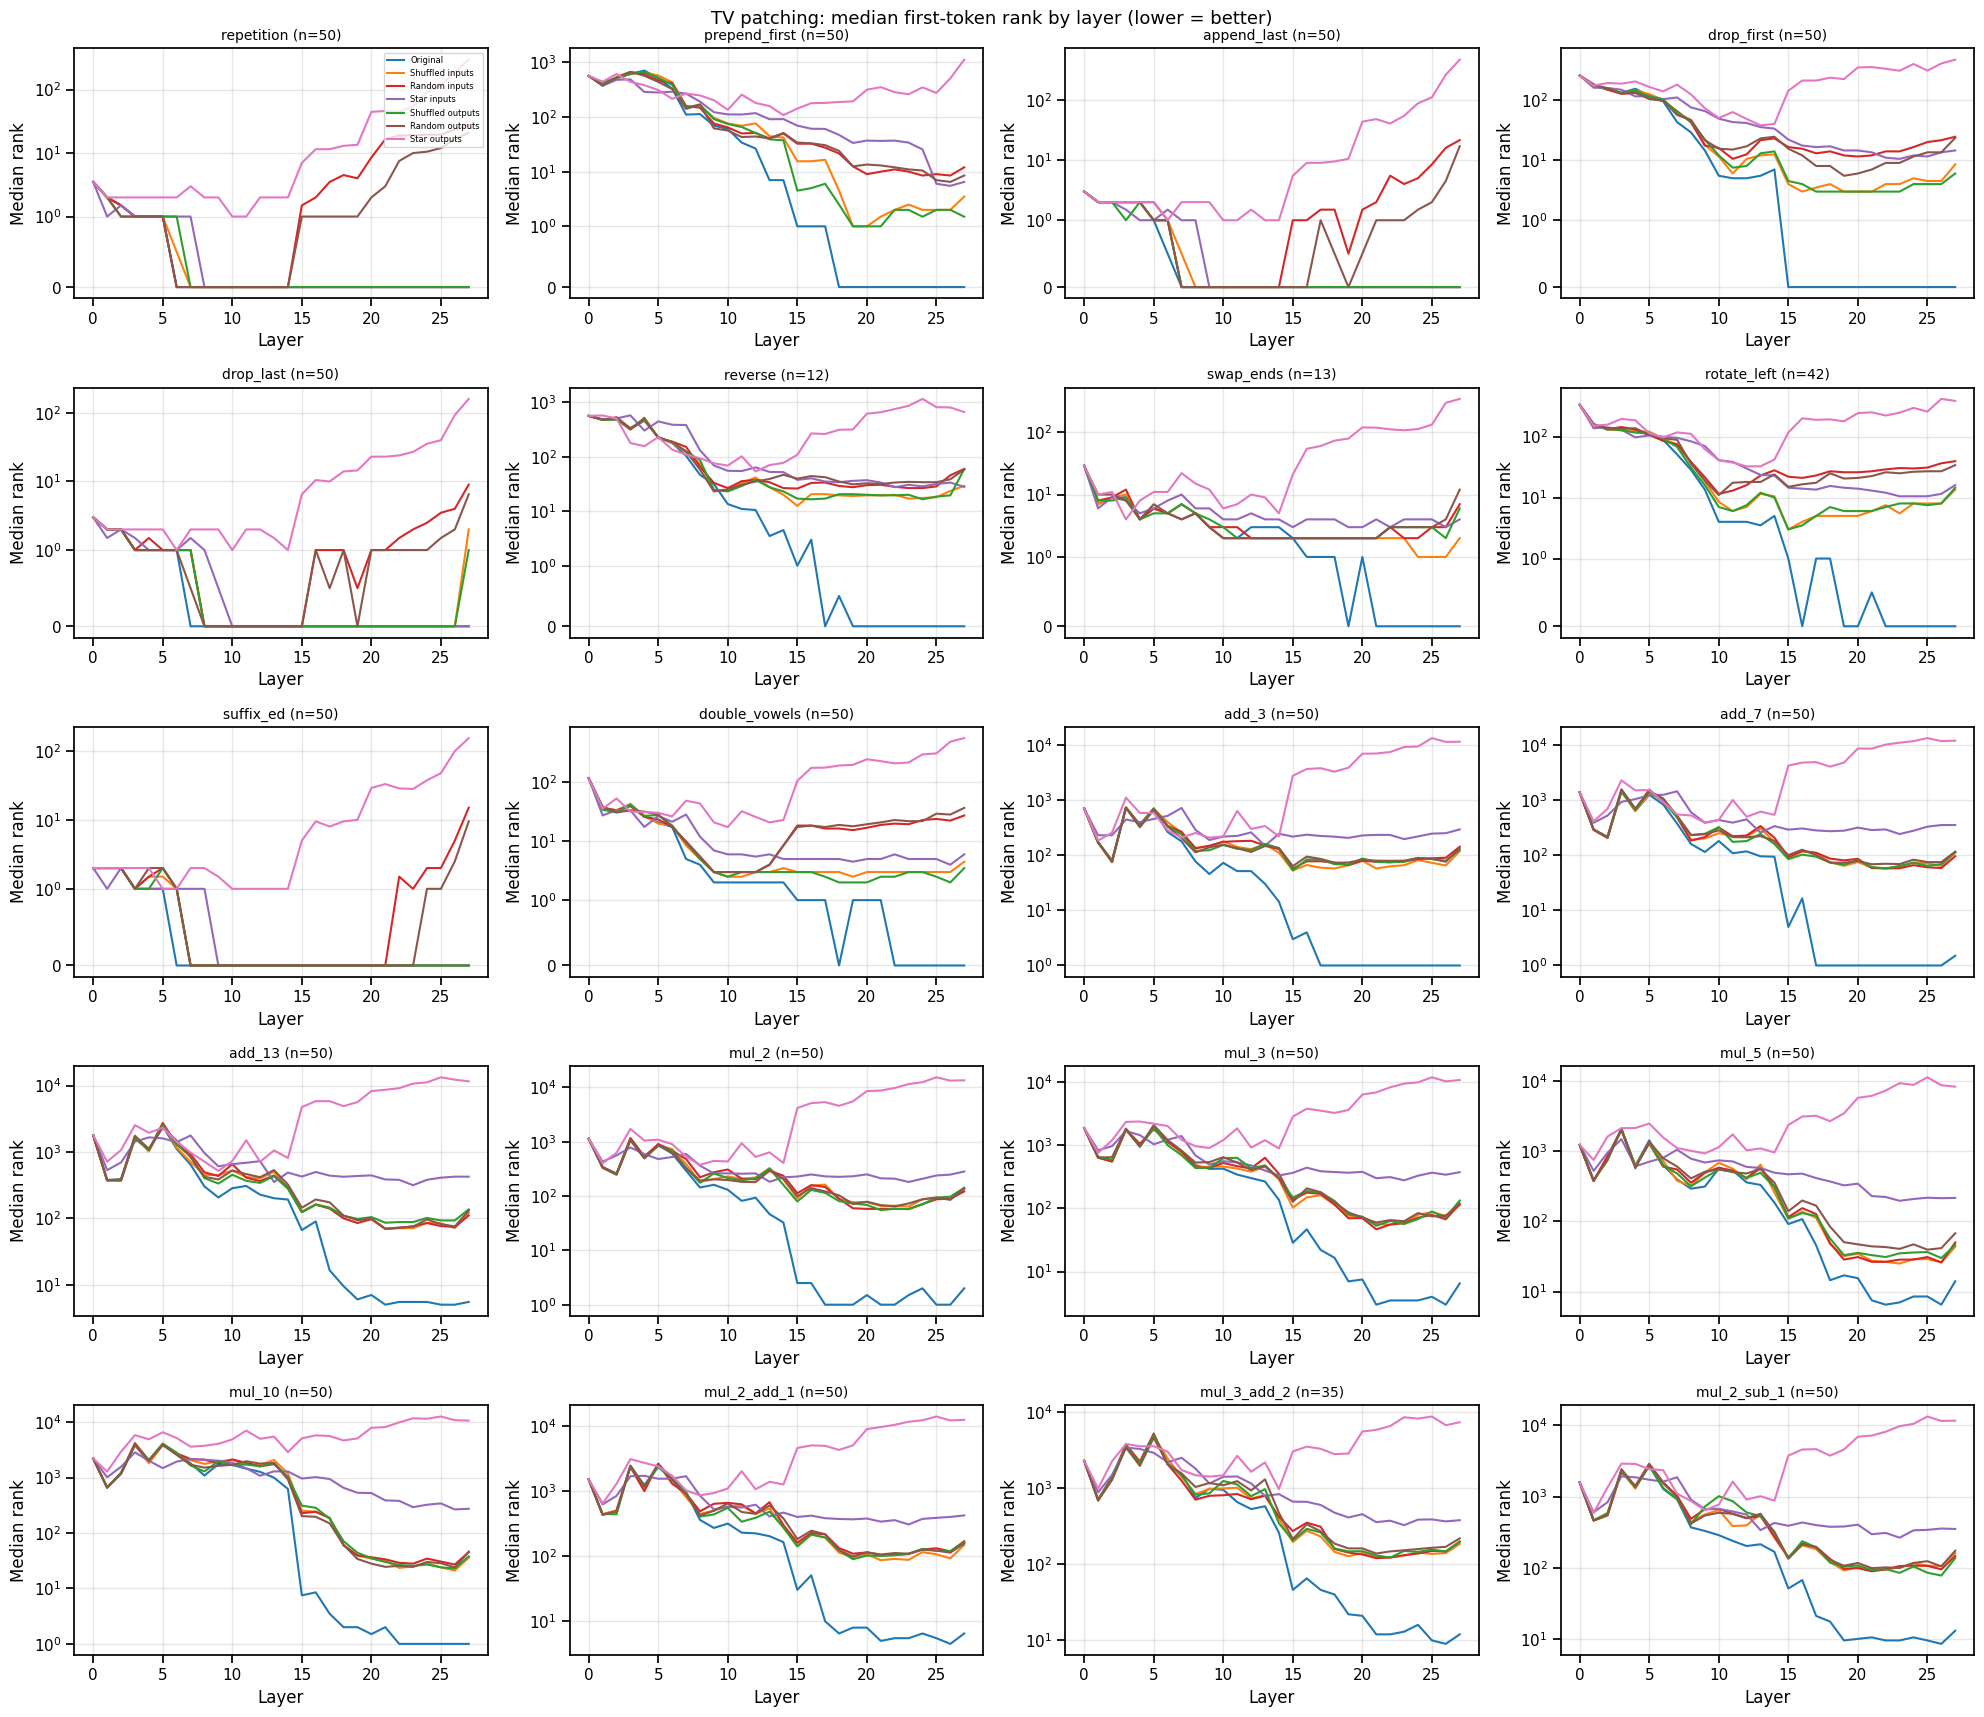

In [ ]:
# === TV patching: recovery accuracy by layer, per task (95% CI) ===
cond_colors = {
    'orig':              'tab:blue',
    'shuffled_inputs':   'tab:orange',
    'random_inputs':     'tab:red',
    'star_inputs':       'tab:purple',
    'shuffled_outputs':  'tab:green',
    'random_outputs':    'tab:brown',
    'star_outputs':      'tab:pink',
}
cond_labels = {
    'orig':              'Original',
    'shuffled_inputs':   'Shuffled inputs',
    'random_inputs':     'Random inputs',
    'star_inputs':       'Star inputs',
    'shuffled_outputs':  'Shuffled outputs',
    'random_outputs':    'Random outputs',
    'star_outputs':      'Star outputs',
}

n_t = len(TASK_NAMES_ACTIVE)
n_cols = 4
n_rows = int(np.ceil(n_t / n_cols))
layers = np.arange(n_layers)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows))
axes = np.array(axes).flatten()
for ax, name in zip(axes, TASK_NAMES_ACTIVE):
    data = patch_acc[name]
    n = data['orig'].shape[0]
    for cond in PATCH_CONDS:
        mean = data[cond].mean(axis=0)
        se = data[cond].std(axis=0) / np.sqrt(n)
        ax.plot(layers, mean, color=cond_colors[cond],
                label=cond_labels[cond], lw=1.5)
        ax.fill_between(layers, mean - 1.96*se, mean + 1.96*se,
                        color=cond_colors[cond], alpha=0.15)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Layer'); ax.set_ylabel('Recovery accuracy')
    ax.set_title(f'{name} (n={n})', fontsize=10)
    ax.grid(True, alpha=0.3)
axes[0].legend(fontsize=6, loc='upper left')
for ax in axes[n_t:]: ax.set_visible(False)
fig.suptitle('TV patching: recovery accuracy by layer (resid_post, held-out query, 95% CI)', fontsize=13)
plt.tight_layout(); plt.show()

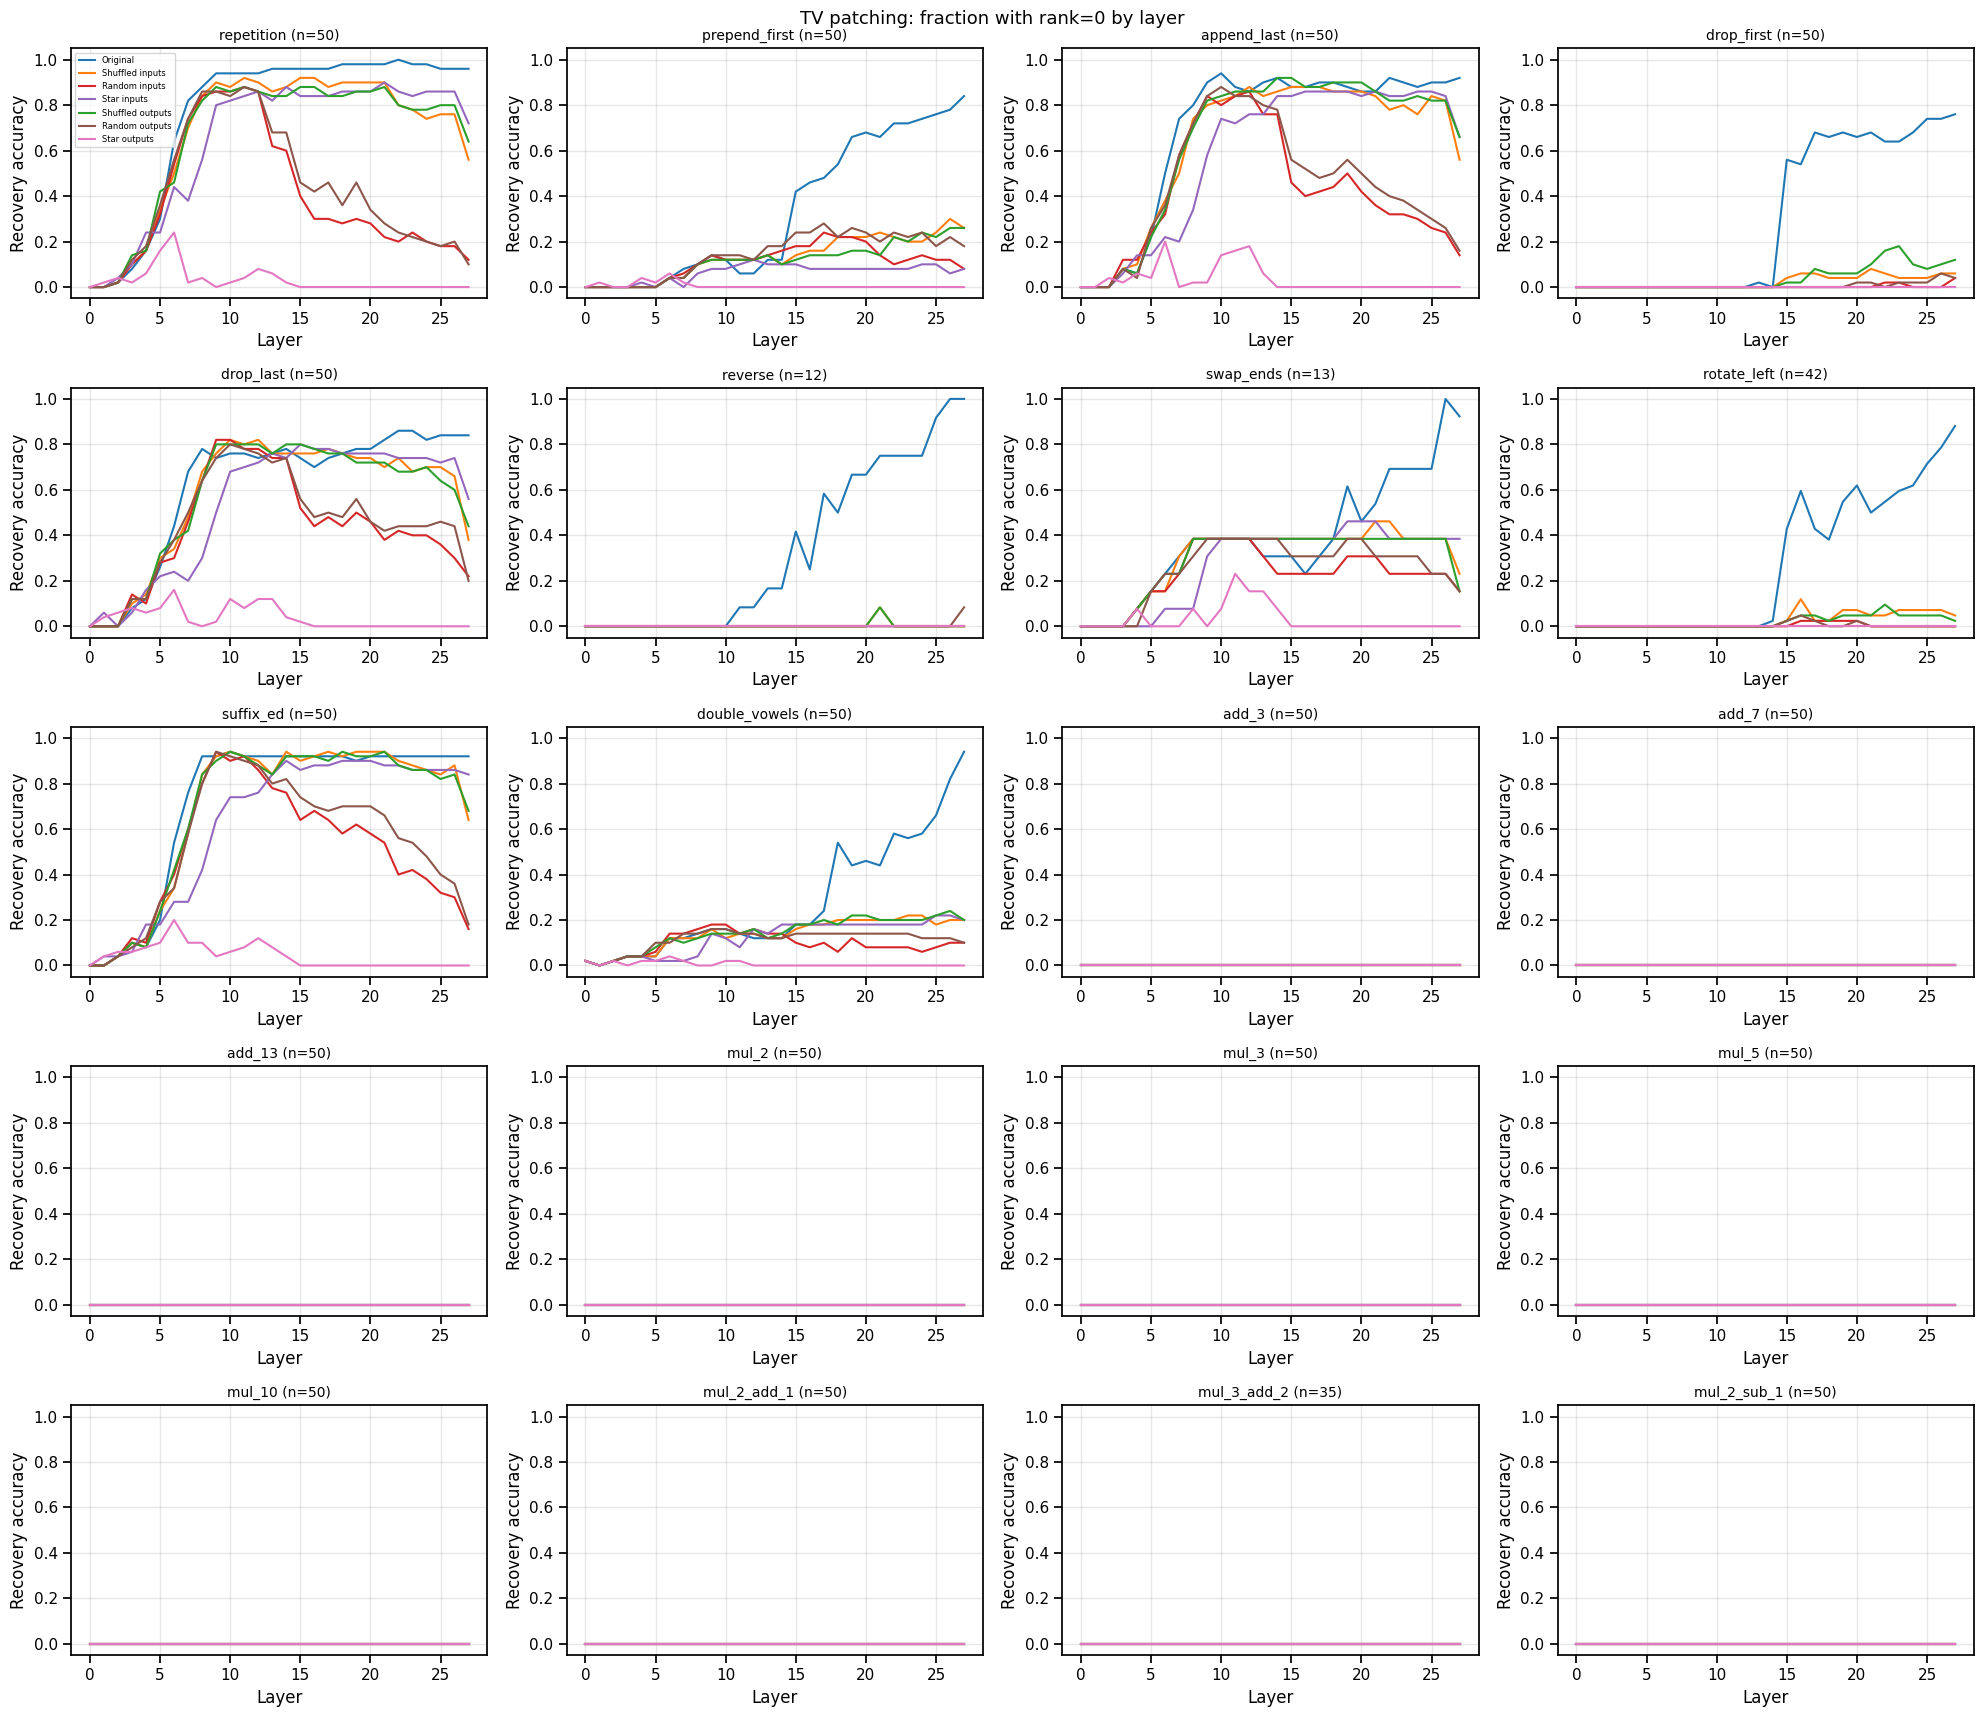

: 

In [ ]:
avg_groups = {
    'Nonce tasks': nonce_active,
    'Arithmetic tasks': arith_active,
    'All tasks': TASK_NAMES_ACTIVE,
}
layers = np.arange(n_layers)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (group_label, task_list) in zip(axes, avg_groups.items()):
    for cond in PATCH_CONDS:
        stacked = np.concatenate([patch_acc[name][cond] for name in task_list], axis=0)
        mean = stacked.mean(axis=0)
        se = stacked.std(axis=0) / np.sqrt(stacked.shape[0])
        ax.plot(layers, mean, color=cond_colors[cond],
                label=cond_labels[cond], lw=1.5)
        ax.fill_between(layers, mean - 1.96*se, mean + 1.96*se,
                        color=cond_colors[cond], alpha=0.15)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Layer'); ax.set_ylabel('Recovery accuracy')
    n_prompts = sum(patch_acc[name]['orig'].shape[0] for name in task_list)
    ax.set_title(f'{group_label} (n={n_prompts})', fontsize=11)
    ax.grid(True, alpha=0.3)
axes[0].legend(fontsize=7, loc='upper left')
fig.suptitle('TV patching: recovery accuracy by layer, averaged across tasks (95% CI)', fontsize=13)
plt.tight_layout(); plt.show()

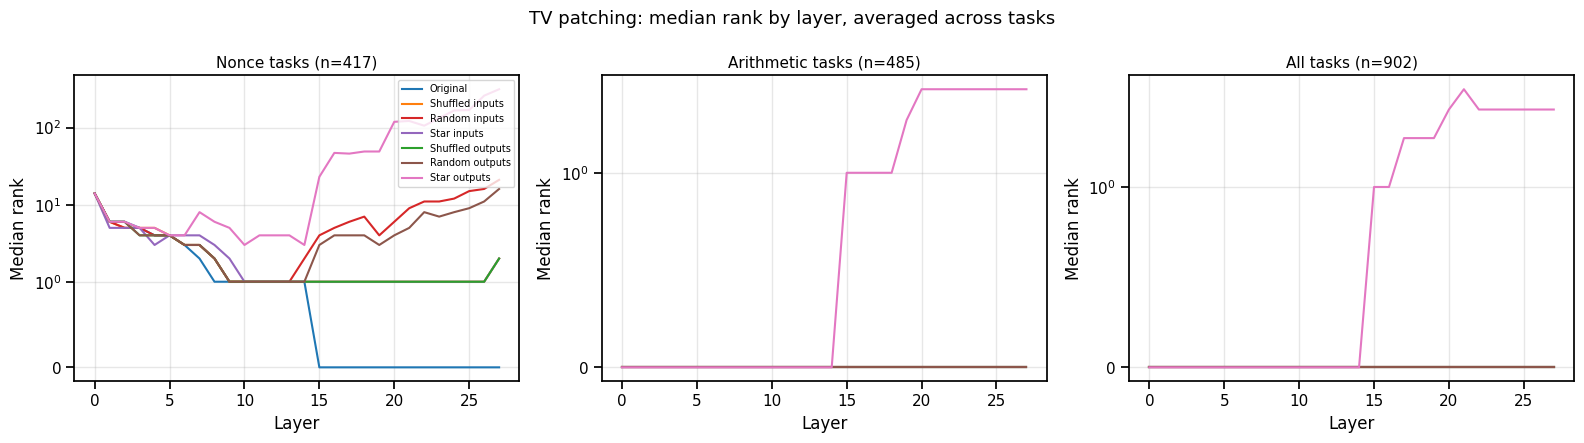

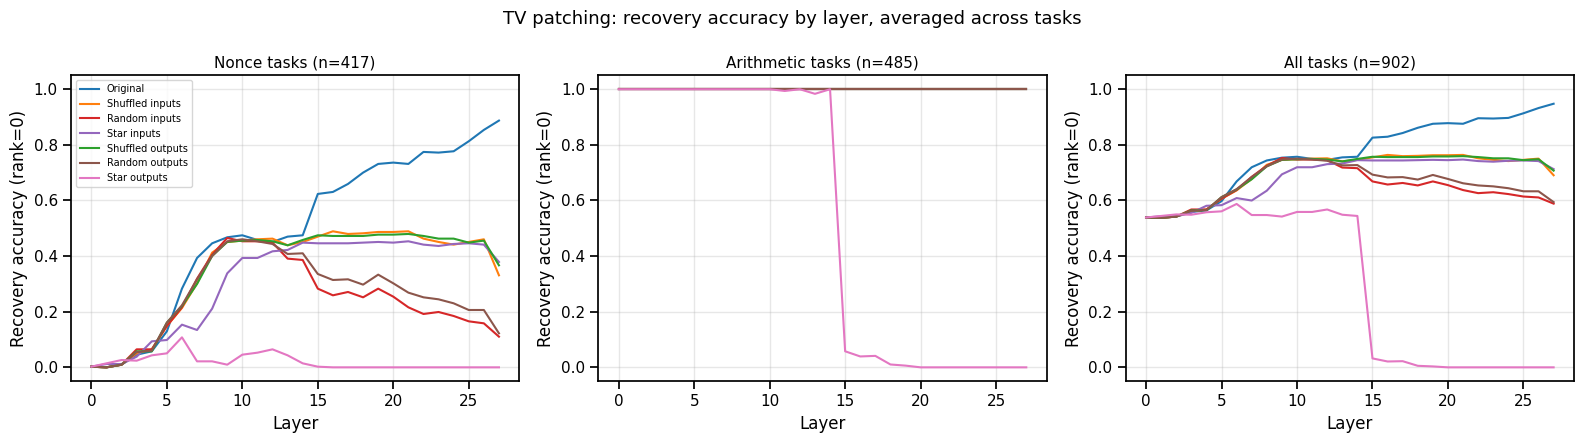

In [70]:
# === TV patching averaged by task category ===

avg_groups = {
    'Nonce tasks': nonce_active,
    'Arithmetic tasks': arith_active,
    'All tasks': TASK_NAMES_ACTIVE,
}
layers = np.arange(n_layers)

# --- Median rank trajectories ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (group_label, task_list) in zip(axes, avg_groups.items()):
    for cond in PATCH_CONDS:
        # Stack all prompts across tasks in this group, take median per layer
        stacked = np.concatenate([patch_rank[name][cond] for name in task_list], axis=0)
        median_rank = np.median(stacked, axis=0)
        ax.plot(layers, median_rank, color=cond_colors[cond],
                label=cond_labels[cond], lw=1.5)
    ax.set_yscale('symlog', linthresh=1)
    ax.set_xlabel('Layer'); ax.set_ylabel('Median rank')
    n_prompts = sum(patch_rank[name]['orig'].shape[0] for name in task_list)
    ax.set_title(f'{group_label} (n={n_prompts})', fontsize=11)
    ax.grid(True, alpha=0.3)
axes[0].legend(fontsize=7, loc='upper right')
fig.suptitle('TV patching: median rank by layer, averaged across tasks', fontsize=13)
plt.tight_layout(); plt.show()

# --- Recovery accuracy (rank=0) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (group_label, task_list) in zip(axes, avg_groups.items()):
    for cond in PATCH_CONDS:
        stacked = np.concatenate([patch_rank[name][cond] for name in task_list], axis=0)
        acc = (stacked == 0).mean(axis=0)
        ax.plot(layers, acc, color=cond_colors[cond],
                label=cond_labels[cond], lw=1.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Layer'); ax.set_ylabel('Recovery accuracy (rank=0)')
    n_prompts = sum(patch_rank[name]['orig'].shape[0] for name in task_list)
    ax.set_title(f'{group_label} (n={n_prompts})', fontsize=11)
    ax.grid(True, alpha=0.3)
axes[0].legend(fontsize=7, loc='upper left')
fig.suptitle('TV patching: recovery accuracy by layer, averaged across tasks', fontsize=13)
plt.tight_layout(); plt.show()

In [73]:
# === Diagnostic: what's actually happening in arithmetic patching? ===

# Pick one arithmetic example
name = 'add_3'
pdata = TASKS[name][0]
ans = pdata['query_output']
qi = pdata['query_input']
print(f'Task: {name}, query: {qi}, answer: {ans}')

zs_prompt = f'{qi} →'
zs_tokens = model.to_tokens(zs_prompt, prepend_bos=True)
zs_last = zs_tokens.shape[1] - 1
print(f'zs_tokens shape: {zs_tokens.shape}, zs_last: {zs_last}')
print(f'zs decoded: {[model.tokenizer.decode([t]) for t in zs_tokens[0]]}')

# Target tokenization
target_toks = model.to_tokens(' ' + ans.strip(), prepend_bos=False)[0]
space_id = model.to_tokens(' ', prepend_bos=False)[0, 0].item()
print(f'Target tokens: {[(model.tokenizer.decode([t]), t.item(), t.item()==space_id) for t in target_toks]}')

# Check: what does zero-shot give WITHOUT hooks, but with space appended?
cur_with_space = torch.cat([zs_tokens, target_toks[0:1].unsqueeze(0).to(zs_tokens.device)], dim=1)
print(f'cur_with_space shape: {cur_with_space.shape}')
with torch.no_grad():
    logits_zs = model(cur_with_space)[0, -1]
ans_tok = target_toks[1].item()  # the non-space token
rank_zs = int((logits_zs > logits_zs[ans_tok]).sum().item())
print(f'Zero-shot rank (with space fed): {rank_zs}')

# Now check patching at layers 0, 7, 14, 21
cond_prompt = task_cond_prompts[name][0]['orig']
cond_tokens = model.to_tokens(cond_prompt, prepend_bos=True)
cond_last = cond_tokens.shape[1] - 1
with torch.no_grad():
    _, cache = model.run_with_cache(cond_tokens, names_filter=RESID_FILTER)
icl_resids = {L: cache['resid_pre', L][0, cond_last].clone() for L in range(n_layers)}
del cache; torch.cuda.empty_cache()

for L in [0, 7, 14, 21]:
    rep = icl_resids[L]
    def patch_hook(resid, hook, _rep=rep, _pos=zs_last):
        resid[0, _pos, :] = _rep.to(resid.dtype)
        return resid
    hooks = [(f'blocks.{L}.hook_resid_pre', patch_hook)]
    # Do what first_content_token_rank does manually
    cur = torch.cat([zs_tokens, target_toks[0:1].unsqueeze(0).to(zs_tokens.device)], dim=1)
    with torch.no_grad():
        logits_patched = model.run_with_hooks(cur, fwd_hooks=hooks)[0, -1]
    rank_patched = int((logits_patched > logits_patched[ans_tok]).sum().item())
    
    # Also check: what if we DON'T feed the space?
    with torch.no_grad():
        logits_no_space = model.run_with_hooks(zs_tokens, fwd_hooks=hooks)[0, -1]
    # Check rank of space token itself
    rank_space = int((logits_no_space > logits_no_space[space_id]).sum().item())
    # And rank of answer token at this position
    rank_ans_nospace = int((logits_no_space > logits_no_space[ans_tok]).sum().item())
    
    print(f'L{L:2d}: patched rank={rank_patched}, '
          f'space_rank_at_arrow={rank_space}, ans_rank_at_arrow={rank_ans_nospace}')

Task: add_3, query: 22, answer: 25
zs_tokens shape: torch.Size([1, 3]), zs_last: 2
zs decoded: ['<|begin_of_text|>', '22', ' →']
Target tokens: [(' ', 220, True), ('25', 914, False)]
cur_with_space shape: torch.Size([1, 4])
Zero-shot rank (with space fed): 3
L 0: patched rank=3, space_rank_at_arrow=0, ans_rank_at_arrow=413
L 7: patched rank=3, space_rank_at_arrow=0, ans_rank_at_arrow=71
L14: patched rank=2, space_rank_at_arrow=0, ans_rank_at_arrow=5
L21: patched rank=0, space_rank_at_arrow=0, ans_rank_at_arrow=1


## TV patching: first-token rank by layer and condition, per task

Lower rank = better recovery. Rank 0 = correct answer is top prediction.

In [ ]:
cond_colors = {
    'orig':              'tab:blue',
    'shuffled_inputs':   'tab:orange',
    'random_inputs':     'tab:red',
    'star_inputs':       'tab:purple',
    'shuffled_outputs':  'tab:green',
    'random_outputs':    'tab:brown',
    'star_outputs':      'tab:pink',
}
cond_labels = {
    'orig':              'Original',
    'shuffled_inputs':   'Shuffled inputs',
    'random_inputs':     'Random inputs',
    'star_inputs':       'Star inputs',
    'shuffled_outputs':  'Shuffled outputs',
    'random_outputs':    'Random outputs',
    'star_outputs':      'Star outputs',
}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows))
axes = np.array(axes).flatten()
layers = np.arange(n_layers)
for ax, name in zip(axes, TASK_NAMES_ACTIVE):
    for cond in PATCH_CONDS:
        median_rank = np.median(patch_rank[name][cond], axis=0)
        ax.plot(layers, median_rank, color=cond_colors[cond],
                label=cond_labels[cond], lw=1.5)
    ax.set_yscale('symlog', linthresh=1)
    ax.set_xlabel('Layer'); ax.set_ylabel('Median rank')
    ax.set_title(name, fontsize=10)
    ax.grid(True, alpha=0.3)
axes[0].legend(fontsize=6, loc='upper right')
for ax in axes[n_t:]: ax.set_visible(False)
fig.suptitle('TV patching: median first-token rank by layer (lower = better)', fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows))
axes = np.array(axes).flatten()
for ax, name in zip(axes, TASK_NAMES_ACTIVE):
    for cond in PATCH_CONDS:
        acc = (patch_rank[name][cond] == 0).mean(axis=0)
        ax.plot(layers, acc, color=cond_colors[cond],
                label=cond_labels[cond], lw=1.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Layer'); ax.set_ylabel('Recovery accuracy')
    ax.set_title(name, fontsize=10)
    ax.grid(True, alpha=0.3)
axes[0].legend(fontsize=6, loc='upper left')
for ax in axes[n_t:]: ax.set_visible(False)
fig.suptitle('TV patching: fraction with rank=0 (first-token exact recovery)', fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
peak_acc = np.zeros((len(TASK_NAMES_ACTIVE), len(PATCH_CONDS)))
peak_layer = np.zeros((len(TASK_NAMES_ACTIVE), len(PATCH_CONDS)), dtype=int)
for i, name in enumerate(TASK_NAMES_ACTIVE):
    for j, cond in enumerate(PATCH_CONDS):
        acc_by_layer = (patch_rank[name][cond] == 0).mean(axis=0)
        peak_acc[i, j] = acc_by_layer.max()
        peak_layer[i, j] = acc_by_layer.argmax()

fig, ax = plt.subplots(figsize=(8, max(6, len(TASK_NAMES_ACTIVE) * 0.45)))
im = ax.imshow(peak_acc, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Peak recovery accuracy')
ax.set_xticks(range(len(PATCH_CONDS)))
ax.set_xticklabels([cond_labels[c] for c in PATCH_CONDS], rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(TASK_NAMES_ACTIVE)))
ax.set_yticklabels(TASK_NAMES_ACTIVE, fontsize=9)
for i in range(len(TASK_NAMES_ACTIVE)):
    for j in range(len(PATCH_CONDS)):
        ax.text(j, i, f'{peak_acc[i,j]:.2f}\nL{peak_layer[i,j]}',
                ha='center', va='center', fontsize=7,
                color='white' if peak_acc[i,j] > 0.5 else 'black')
ax.set_title('Peak TV recovery accuracy (with peak layer)')
plt.tight_layout(); plt.show()